In [2]:
cd /home/dmoi/projects/yeast_fusion_segmenter

/home/dmoi/projects/yeast_fusion_segmenter


In [3]:
#load and vis a few seqmented images in the images_CNN folder
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from PIL import Image, ImageSequence

#is this a joke or something! respect a naming convention please and stick to it!

img_list = glob.glob('Images_mk3/F*_im.TIF')+glob.glob('Images_mk3/F*_im.tif')
img_list = sorted(img_list)
mask_list = glob.glob('Images_mk3/F*_mask.h5')
mask_list = sorted(mask_list)
fluo_gfp = glob.glob('Images_mk3/*GFP_im.TIF')+glob.glob('Images_mk3/*GFP_im.tif')
fluo_gfp = sorted(fluo_gfp) 
fluo_rfp = glob.glob('Images_mk3/*RFP_im.TIF')+glob.glob('Images_mk3/*RFP_im.tif')
fluo_rfp = sorted(fluo_rfp)

#change to dictionary with number as key
img_list = { int(file.split('/')[-1].split('_')[0].replace('F', '')):file for file in img_list }
mask_list = { int(file.split('/')[-1].split('_')[0].replace('F', '')):file for file in mask_list }
fluo_gfp = { int(file.split('/')[-1].split('_')[0].replace('F', '')):file for file in fluo_gfp }
fluo_rfp = { int(file.split('/')[-1].split('_')[0].replace('F', '')):file for file in fluo_rfp }

print( len(img_list), len(mask_list) , len(fluo_gfp), len(fluo_rfp  )   )
dataset = {}
for i in range(1,len(img_list)):
	try:
		dataset[i] = { 'img': img_list[i], 'mask': mask_list[i], 'gfp': fluo_gfp[i], 'rfp': fluo_rfp[i]  }
	except KeyError:
		print(f"Missing data for sample {i}, skipping.")
		
		continue
print(dataset)

25 25 24 24
Missing data for sample 15, skipping.
Missing data for sample 16, skipping.
{1: {'img': 'Images_mk3/F1_im.TIF', 'mask': 'Images_mk3/F1_mask.h5', 'gfp': 'Images_mk3/F1_GFP_im.TIF', 'rfp': 'Images_mk3/F1_RFP_im.TIF'}, 2: {'img': 'Images_mk3/F2_im.TIF', 'mask': 'Images_mk3/F2_mask.h5', 'gfp': 'Images_mk3/F2_GFP_im.TIF', 'rfp': 'Images_mk3/F2_RFP_im.TIF'}, 3: {'img': 'Images_mk3/F3_im.TIF', 'mask': 'Images_mk3/F3_mask.h5', 'gfp': 'Images_mk3/F3_GFP_im.TIF', 'rfp': 'Images_mk3/F3_RFP_im.TIF'}, 4: {'img': 'Images_mk3/F4_im.TIF', 'mask': 'Images_mk3/F4_mask.h5', 'gfp': 'Images_mk3/F4_GFP_im.TIF', 'rfp': 'Images_mk3/F4_RFP_im.TIF'}, 5: {'img': 'Images_mk3/F5_im.TIF', 'mask': 'Images_mk3/F5_mask.h5', 'gfp': 'Images_mk3/F5_GFP_im.TIF', 'rfp': 'Images_mk3/F5_RFP_im.TIF'}, 6: {'img': 'Images_mk3/F6_im.TIF', 'mask': 'Images_mk3/F6_mask.h5', 'gfp': 'Images_mk3/F6_GFP_im.TIF', 'rfp': 'Images_mk3/F6_RFP_im.TIF'}, 7: {'img': 'Images_mk3/F7_im.TIF', 'mask': 'Images_mk3/F7_mask.h5', 'gfp': 'I

In [4]:
print(dataset)

{1: {'img': 'Images_mk3/F1_im.TIF', 'mask': 'Images_mk3/F1_mask.h5', 'gfp': 'Images_mk3/F1_GFP_im.TIF', 'rfp': 'Images_mk3/F1_RFP_im.TIF'}, 2: {'img': 'Images_mk3/F2_im.TIF', 'mask': 'Images_mk3/F2_mask.h5', 'gfp': 'Images_mk3/F2_GFP_im.TIF', 'rfp': 'Images_mk3/F2_RFP_im.TIF'}, 3: {'img': 'Images_mk3/F3_im.TIF', 'mask': 'Images_mk3/F3_mask.h5', 'gfp': 'Images_mk3/F3_GFP_im.TIF', 'rfp': 'Images_mk3/F3_RFP_im.TIF'}, 4: {'img': 'Images_mk3/F4_im.TIF', 'mask': 'Images_mk3/F4_mask.h5', 'gfp': 'Images_mk3/F4_GFP_im.TIF', 'rfp': 'Images_mk3/F4_RFP_im.TIF'}, 5: {'img': 'Images_mk3/F5_im.TIF', 'mask': 'Images_mk3/F5_mask.h5', 'gfp': 'Images_mk3/F5_GFP_im.TIF', 'rfp': 'Images_mk3/F5_RFP_im.TIF'}, 6: {'img': 'Images_mk3/F6_im.TIF', 'mask': 'Images_mk3/F6_mask.h5', 'gfp': 'Images_mk3/F6_GFP_im.TIF', 'rfp': 'Images_mk3/F6_RFP_im.TIF'}, 7: {'img': 'Images_mk3/F7_im.TIF', 'mask': 'Images_mk3/F7_mask.h5', 'gfp': 'Images_mk3/F7_GFP_im.TIF', 'rfp': 'Images_mk3/F7_RFP_im.TIF'}, 8: {'img': 'Images_mk3/F8_

In [5]:
#clean the images CNN clean folder
import shutil
shutil.rmtree('images_CNN_clean', ignore_errors=True)
os.makedirs('images_CNN_clean', exist_ok=True)

In [6]:
try:
	os.mkdir('images_CNN_clean')
except:
	pass

count = 0 
for i in dataset:
	count += 1
	#copy the  files with standard names
	os.system('cp '+dataset[i]['img']+' images_CNN_clean/F'+str(count).zfill(2)+'_im.TIF')
	os.system('cp '+dataset[i]['mask']+' images_CNN_clean/F'+str(count).zfill(2)+'_mask.h5')
	os.system('cp '+dataset[i]['gfp']+' images_CNN_clean/F'+str(count).zfill(2)+'_GFP_im.TIF')
	os.system('cp '+dataset[i]['rfp']+' images_CNN_clean/F'+str(count).zfill(2)+'_RFP_im.TIF')

In [7]:
img_list = glob.glob('images_CNN_clean/F?_im.TIF')+glob.glob('images_CNN_clean/F??_im.TIF')
img_list = sorted(img_list)
mask_list = glob.glob('images_CNN_clean/F*_mask.h5')
mask_list = sorted(mask_list)
fluo_gfp = glob.glob('images_CNN_clean/*GFP_im.TIF')
fluo_gfp = sorted(fluo_gfp) 
fluo_rfp = glob.glob('images_CNN_clean/*RFP_im.TIF')
fluo_rfp = sorted(fluo_rfp)
print( len(img_list), len(mask_list) , len(fluo_gfp), len(fluo_rfp  )   )
dataset = {}
for i in range(len(img_list)):
	dataset[i] = { 'img': img_list[i], 'mask': mask_list[i], 'gfp': fluo_gfp[i], 'rfp': fluo_rfp[i]  }
print(dataset)

22 22 22 22
{0: {'img': 'images_CNN_clean/F01_im.TIF', 'mask': 'images_CNN_clean/F01_mask.h5', 'gfp': 'images_CNN_clean/F01_GFP_im.TIF', 'rfp': 'images_CNN_clean/F01_RFP_im.TIF'}, 1: {'img': 'images_CNN_clean/F02_im.TIF', 'mask': 'images_CNN_clean/F02_mask.h5', 'gfp': 'images_CNN_clean/F02_GFP_im.TIF', 'rfp': 'images_CNN_clean/F02_RFP_im.TIF'}, 2: {'img': 'images_CNN_clean/F03_im.TIF', 'mask': 'images_CNN_clean/F03_mask.h5', 'gfp': 'images_CNN_clean/F03_GFP_im.TIF', 'rfp': 'images_CNN_clean/F03_RFP_im.TIF'}, 3: {'img': 'images_CNN_clean/F04_im.TIF', 'mask': 'images_CNN_clean/F04_mask.h5', 'gfp': 'images_CNN_clean/F04_GFP_im.TIF', 'rfp': 'images_CNN_clean/F04_RFP_im.TIF'}, 4: {'img': 'images_CNN_clean/F05_im.TIF', 'mask': 'images_CNN_clean/F05_mask.h5', 'gfp': 'images_CNN_clean/F05_GFP_im.TIF', 'rfp': 'images_CNN_clean/F05_RFP_im.TIF'}, 5: {'img': 'images_CNN_clean/F06_im.TIF', 'mask': 'images_CNN_clean/F06_mask.h5', 'gfp': 'images_CNN_clean/F06_GFP_im.TIF', 'rfp': 'images_CNN_clean/F06

In [8]:
from PIL import Image, ImageEnhance
def adjust_brightness_contrast(input_image_path, output_image_path, brightness=3, contrast=3):
	# Open the image
	image = Image.open(input_image_path)
	
	# Adjust brightness
	enhancer = ImageEnhance.Brightness(image)
	image = enhancer.enhance(brightness)
	
	# Adjust contrast
	enhancer = ImageEnhance.Contrast(image)
	image = enhancer.enhance(contrast)
	
	# Save the modified image
	image.save(output_image_path)

In [9]:
import skimage.measure as measure
import copy
def output_contours( m , cl , verbose = False):

	c = []
	for val in list(np.unique(m)):
		sub = copy.deepcopy(m)
		sub[sub!=val]= 0
		c+= measure.find_contours(sub, .9)
	contours = c
	
	if verbose == True:
		plt.imshow(m)
		plt.title( 'contours ' + str(cl) ) 
		for n, contour in enumerate(contours):
			plt.plot(contour[:, 1], contour[:, 0], linewidth=2)
		plt.show()

	#output contours of each mask to file
	#divide x and y coordinates by total image size
	#to get values between 0 and 1  
	#<class-index> <x1> <y1> <x2> <y2> ... <xn> <yn>
	lines = []
	
	for c in contours:
		coords = []
		for i in range(0,c.shape[0]):
			coords.append( (float(c[i][1]) / m.shape[0]) )
			coords.append( (float(c[i][0]) / m.shape[1]) )
		line = str(cl) + ' ' + ' '.join([str(c) for c in coords]) + '\n'
		lines.append(line)
	return lines

def split_mask(mask, crop = 1024 , nclasses = 7 , verbose = False):
	#custom encoding with n classes
	mask = mask[0:crop, 0:crop]
	masks = []
	for i in range( nclasses ):
		newmask = copy.deepcopy(mask)
		#set all values outside class to 0
		newmask[ (newmask < (i*1000)) | (newmask >= ((i+1)*1000)) ] = 0
		masks.append(newmask)
	if verbose == True:
		for i,m in enumerate(masks):
			plt.imshow(m)
			plt.title( 'mask ' + str(i) ) 
			plt.show()
		print('made ' , len(masks) , 'mask channels')
	
	return masks

def mask2contourfile( mask , outputfile , verbose = False):
	if type(mask) == list:
		masks = mask
	else:
		masks = split_mask(mask, verbose = verbose)
	lines = None
	for i,m in enumerate(masks):
		if lines is None:
			lines = output_contours(m, i , verbose = verbose)
		else:
			lines += output_contours(m, i , verbose = verbose)
	with open(outputfile, 'w') as f:
		for l in lines:
			f.write(l)
	return  outputfile


In [10]:
#clean finaldataset folder
import shutil
overwite = True
if overwite:
	try:
		shutil.rmtree('./datasets/')
	except:
		pass
	os.mkdir('./datasets/')
	os.mkdir('./datasets/train')
	os.mkdir('./datasets/train/images/')
	os.mkdir('./datasets/train/labels/')
	
	os.mkdir('./datasets/test')
	os.mkdir('./datasets/test/images/')
	os.mkdir('./datasets/test/labels/')
	
	os.mkdir('./datasets/val/')
	os.mkdir('./datasets/val/images')
	os.mkdir('./datasets/val/labels')


In [11]:
#stack equivalent frames together from img, gfp and rfp and transform them to a jpg image
import cv2
import numpy as np
import os
import tqdm

verbose = False
crop = 1024



def yield_frames(img,crop=1024 , verbose = False ,scaler = True):
	for i, page in enumerate(ImageSequence.Iterator(img)):
		if verbose == True:
			plt.imshow(np.array(page))
			plt.show()
		if crop is not None:
			page = np.array(page)[0:crop, 0:crop]
		if scaler==True:
			page = (page - page.min()) / (page.max() - page.min()) * 255
		yield page

count = 0


In [12]:

for sample in dataset:
	maskfile = dataset[sample]['mask']
	maskh5 = h5py.File(maskfile, 'r')
	for group in maskh5.keys():
		for frame in maskh5[group]:
			mask = np.array( maskh5[group][frame] ,  dtype = np.uint16 )
			
			if np.sum(mask) > 0 :
				mask =  mask[0:crop, 0:crop]
				dataset[sample]['maskmatrix'] = mask
				print( group, frame)
				print(np.unique(mask) )
				if verbose == True:
					plt.imshow(mask)
					plt.show()
				converted = mask2contourfile(mask, maskfile +'converted.txt' , verbose = verbose)
				dataset[sample]['mask_poly'] = converted
				break

	print('loading img')
	img = Image.open(dataset[sample]['img'])
	img = [frame for frame in yield_frames(img,scaler = True , verbose=verbose)]
	print('loading gfp')
	
	gfp = Image.open(dataset[sample]['gfp'])
	gfp = [frame for frame in yield_frames(gfp,scaler = True,verbose=verbose)]
	
	print('loading rfp')
	rfp = Image.open(dataset[sample]['rfp'])
	rfp = [frame for frame in yield_frames(rfp,scaler = True,verbose=verbose)]
	dataset[sample]['stack']= []
	dataset[sample]['stack_mat'] ={}
	#stack the frames together
	for i in tqdm.tqdm(range(len(img))):
		im = np.stack([img[i], gfp[i], rfp[i]], axis=-1)
		dataset[sample]['stack_mat'][i] = im
		#im = cv2.cvtColor(im, cv2.COLOR_RGB2BGR)
		cv2.imwrite('./datasets/train/images/img_'+str(count)+'.png', im )
		#adjust_brightness_contrast('./datasets/train/images/img_'+str(count)+'.png','./datasets/train/images/img_'+str(count)+'.png')
		dataset[sample]['stack'].append('./datasets/train/images/img_'+str(count)+'.png')
		#save the correct mask file
		shutil.copyfile(dataset[sample]['mask_poly'], './datasets/train/labels/img_'+str(count)+'.txt' )
	count += 1

print('Total images processed: ', count)

FOV0 T5
[   0    1    2    3    4    5    6    7    8   10   11 1001 1002 1003
 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014 1015 1016 1017
 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1031 1032
 1033 1034 1035 1037 1038 1039 1042 1043 1044 1101 1102 1107 2001 2002
 2003 2004 2005 2006 2007 2008 2009 2011]


loading img
loading gfp
loading rfp


100%|██████████| 7/7 [00:00<00:00, 11.95it/s]


FOV0 T5
[   0    1    2    3    4    5    6    7    8    9   10   13  101  102
 1001 1002 1003 1004 1007 1008 1009 1010 1013 1014 1015 1016 1017 1018
 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1030 1031 1032 1033
 1034 1035 1036 1037 1038 1039 1040 1043 1044 1046 1047 1048 1049 1051
 1052 1053 1054 1055 1056 1059 1060 1061 1062 1063 1064 1065 1066 1075
 1076 1077 1078 1101 2001 2002 2003 2006 2101 5001 5002]
loading img
loading gfp
loading rfp


100%|██████████| 7/7 [00:00<00:00, 10.80it/s]


...

100%|██████████| 1/1 [00:00<00:00, 12.90it/s]

FOV0 T0
[   0    1    2    3    4    5    6    7 1003 1004 1006 1007 1008 1009
 1010 1011 1013 1014 1017 1018 1020 1021 1022 1023 1024 1025 1026 1027
 1028 1029 1030 1032 1034 1035 1041 2002 3000 3001 3002 3003 4000 4001
 4002 6000]


loading img
loading gfp
loading rfp


100%|██████████| 1/1 [00:00<00:00, 12.55it/s]

Total images processed:  22


In [13]:
check_example = False
import matplotlib.pyplot as plt
#import edge detection
from skimage import feature
from skimage import measure
%matplotlib inline

if check_example == True:
	print('loading img' )
	img = Image.open(dataset[0]['img'])
	img = [frame for frame in yield_frames(img,verbose=False)]
	print('loading gfp')

	gfp = Image.open(dataset[0]['gfp'])
	gfp = [frame for frame in yield_frames(gfp,verbose=False)]
	
	print('loading rfp')
	rfp = Image.open(dataset[0]['rfp'])
	rfp = [frame for frame in yield_frames(rfp,verbose=False)]

	ax = plt.imshow( img[0] , cmap = 'Greys')
	ax.axes.get_xaxis().set_ticks([])
	ax.axes.get_yaxis().set_ticks([])

	plt.show()
	
	ax = plt.imshow( gfp[0] , cmap = 'Greens')
	ax.axes.get_xaxis().set_ticks([])
	ax.axes.get_yaxis().set_ticks([])

	plt.show()
	
	ax = plt.imshow( rfp[0] , cmap = 'Reds')
	ax.axes.get_xaxis().set_ticks([])
	ax.axes.get_yaxis().set_ticks([])

	plt.show()
	
	
	ax = plt.imshow( dataset[0]['maskmatrix'] )
	ax.axes.get_xaxis().set_ticks([])
	ax.axes.get_yaxis().set_ticks([])

	plt.show()


	for im in dataset:
		
		print('loading img:' , im )
		img = Image.open(dataset[im]['img'])
		img = [frame for frame in yield_frames(img,verbose=False)]
		#increase contrast
		img = [ (frame - frame.min()) / (frame.max() - frame.min()) * 255 for frame in img]
		#apply edge detection to image w skimiage
		edges = feature.canny(img[0], sigma=10)
		
		#scale the mask to 0-1
		mask = dataset[im]['maskmatrix']
		mask = (mask - mask.min()) / (mask.max() - mask.min()) * 1

		#turn edges from boolean to 0-1
		edges = edges.astype(int)

		#scale edges to 0-1
		edges = (edges - edges.min()) / (edges.max() - edges.min()) * 1
		ax = plt.imshow( mask - edges )
		ax.axes.get_xaxis().set_ticks([])
		ax.axes.get_yaxis().set_ticks([])
		plt.show()
		



Found 5 CZI files in new40x folder


The headless flag of imagej.init is deprecated. Use the mode argument instead.


Initialized ImageJ

Processing: new40x/P1_1E3-13.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new40x/P1_1E3-13.czi


Operating in headless mode - the original ImageJ will have limited functionality.


  Image shape: (2120, 2208, 3)
  Detected 3 channels (3D format)
  Channel shapes: []
  Found mask in group 'FOV0', frame 'T0'
  Unique mask values: [   0   10   11   17   18   19   43   44   45   70   71   75  101  102
 1001 1002 1008 1011 1012 1013 1014 1015 1027 1029 1031 1032 1100 1102
 3004 4006 4007 6003 6004 6006 6007 6032 6059 6060 6061]


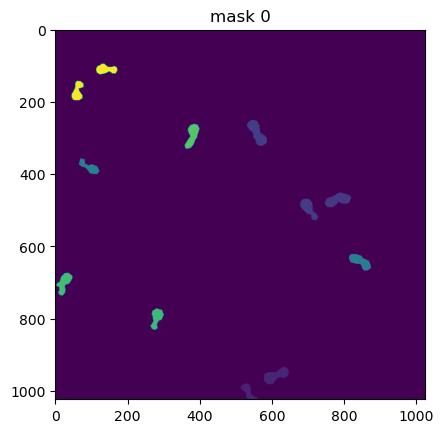

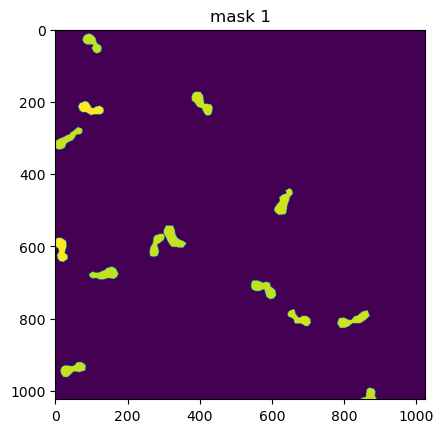

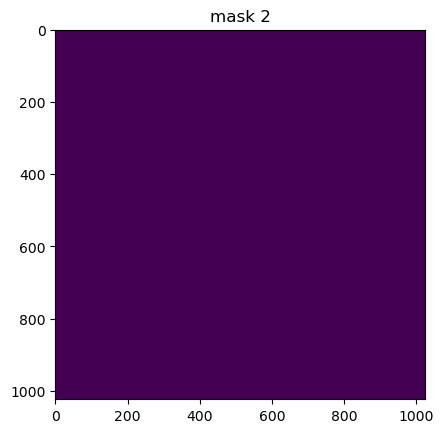

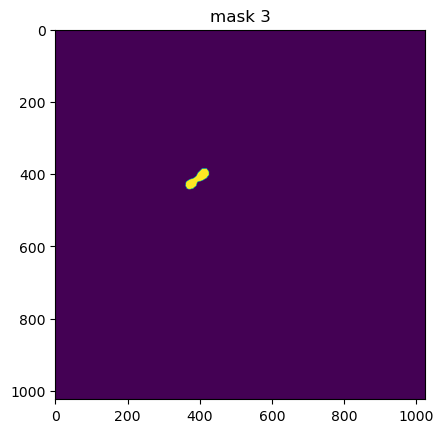

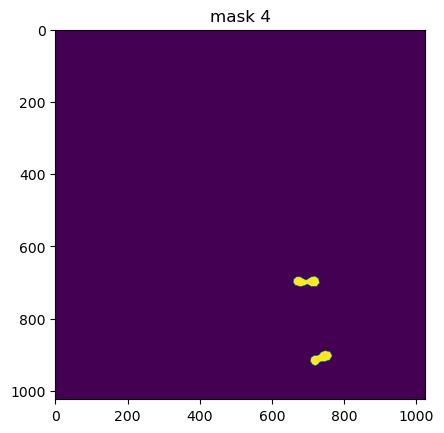

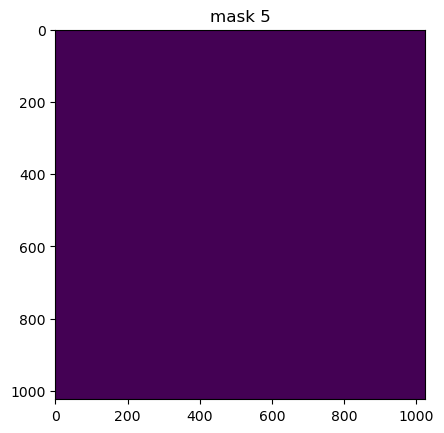

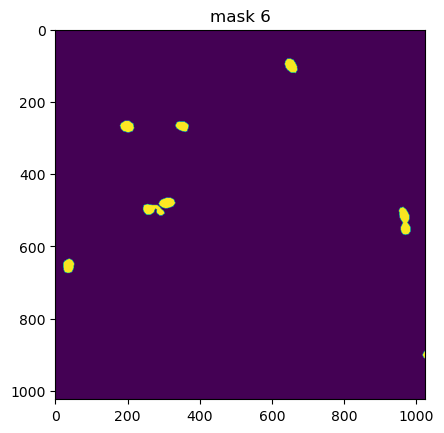

made  7 mask channels


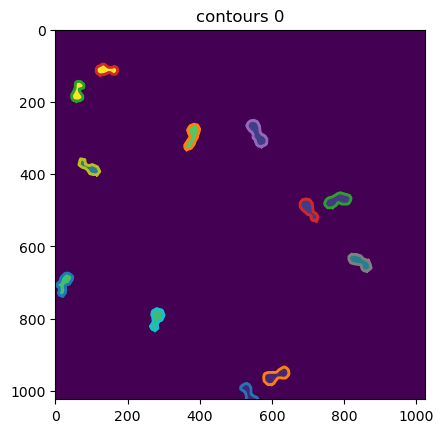

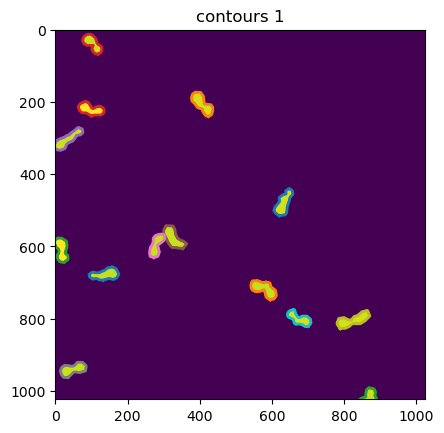

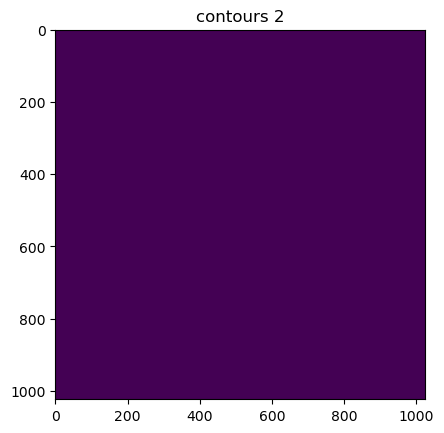

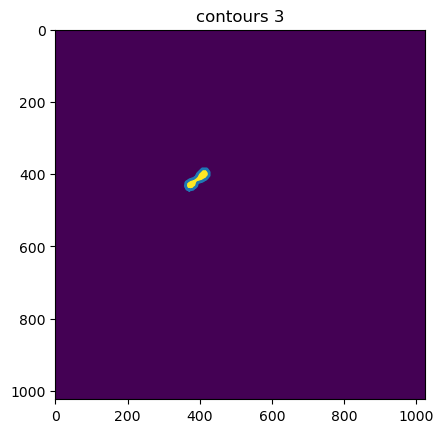

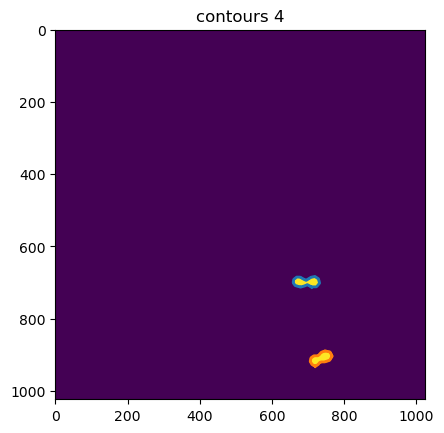

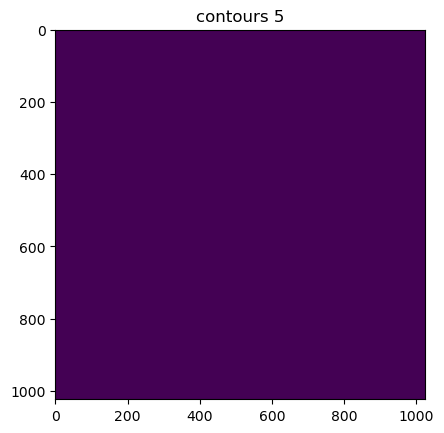

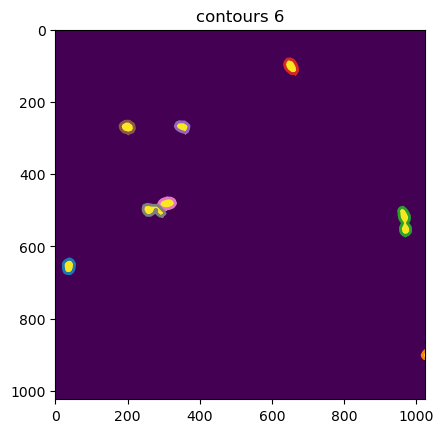

  Saved mask polygons to: new40x/P1_1E3-13_mask_poly.txt
  Saved image to: ./datasets/train/images/P1_1E3-13_22.png
  Saved label to: ./datasets/train/labels/P1_1E3-13_22.txt

Processing: new40x/P1_1G2-09.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new40x/P1_1G2-09.czi
  Image shape: (2120, 2208, 3)
  Detected 3 channels (3D format)
  Channel shapes: []
  Found mask in group 'FOV0', frame 'T0'
  Unique mask values: [   0   16   24   25   26   27   28   38   40   41   42   43   44   45
   46   68   70   71   76   79   80   81   82   84 1013 1018 1025 1026
 1028 1029 1030 1031 1032 1033 1034 1035 1053 1054 1058 1059 1066 1068
 1069 1070 1071 3005 4001 4002 4008 4009 4010 6009 6010 6014 6015 6016
 6037 6038 6039 6040 6046 6047 6049 6050 6051 6052 6053 6054 6059 6060
 6062]


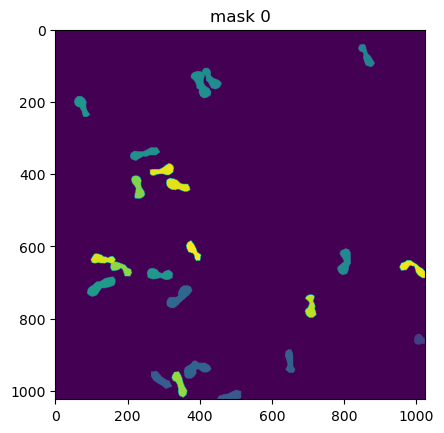

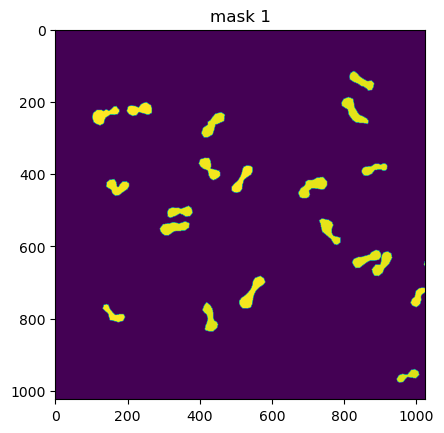

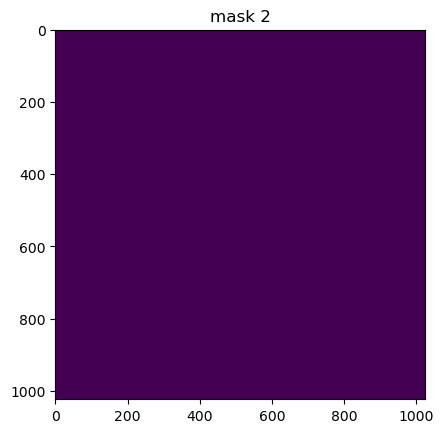

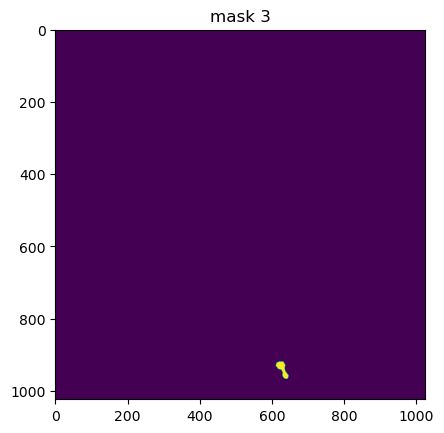

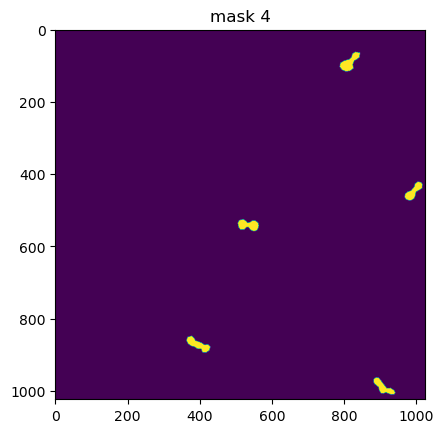

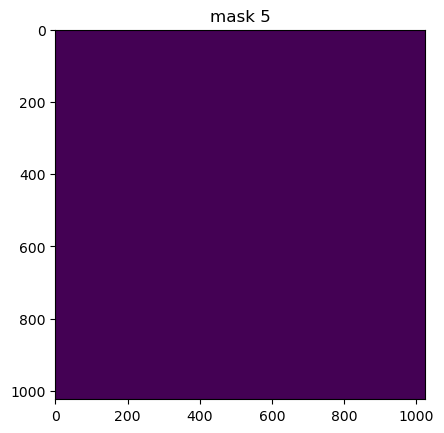

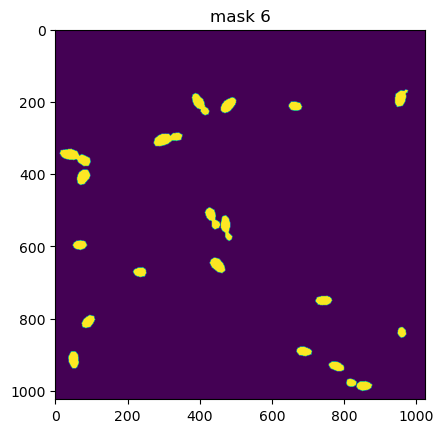

made  7 mask channels


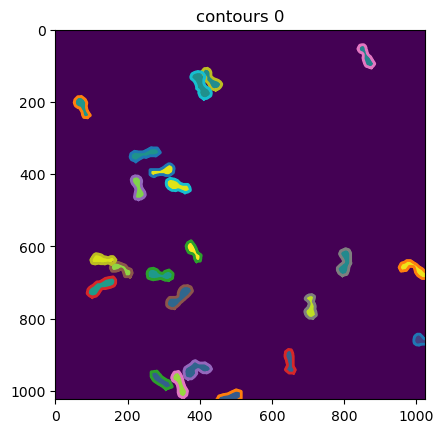

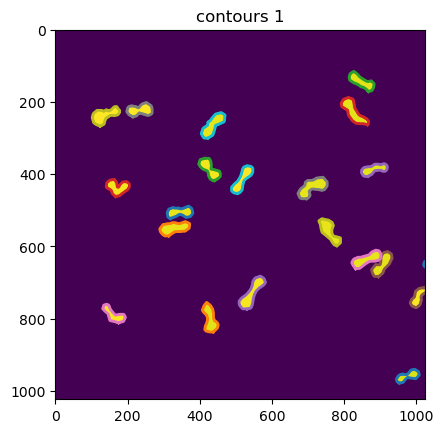

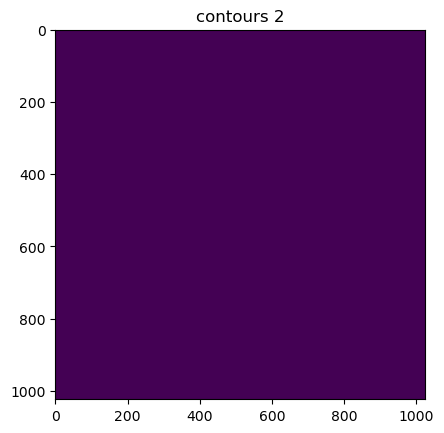

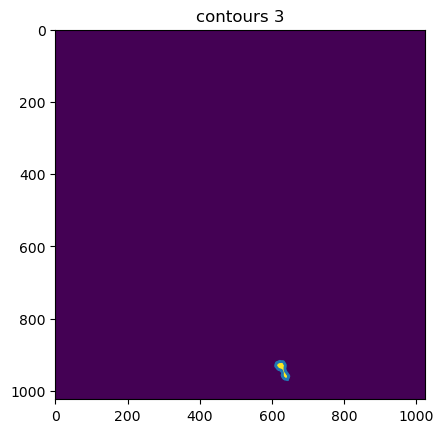

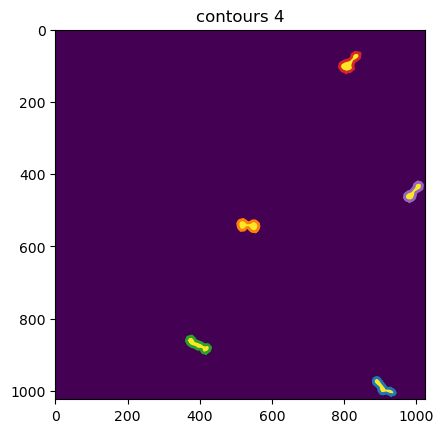

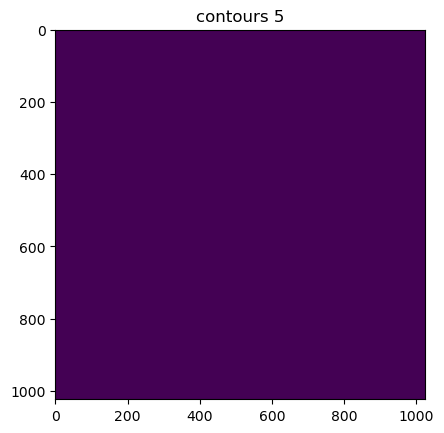

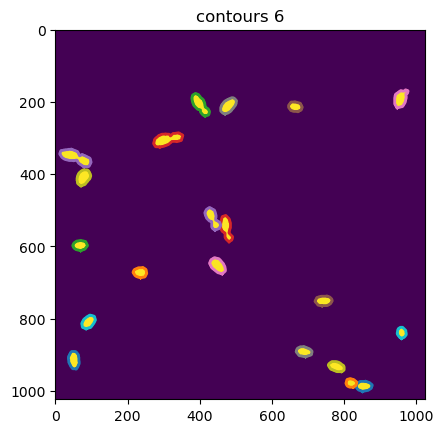

  Saved mask polygons to: new40x/P1_1G2-09_mask_poly.txt
  Saved image to: ./datasets/train/images/P1_1G2-09_23.png
  Saved label to: ./datasets/train/labels/P1_1G2-09_23.txt

Processing: new40x/P1_1G7-08.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new40x/P1_1G7-08.czi
  Image shape: (2120, 2208, 3)
  Detected 3 channels (3D format)
  Channel shapes: []
  Found mask in group 'FOV0', frame 'T0'
  Unique mask values: [   0   14   15   17   22   23   24   25   26   27   28   29 1016 1021
 1022 1029 1030 1031 1032 1033 4010 4012 4013 6032 6038 6039 6040 6041
 6042 6043 6045 6055 6056 6057 6058 6059 6060 6061 6062 6063]


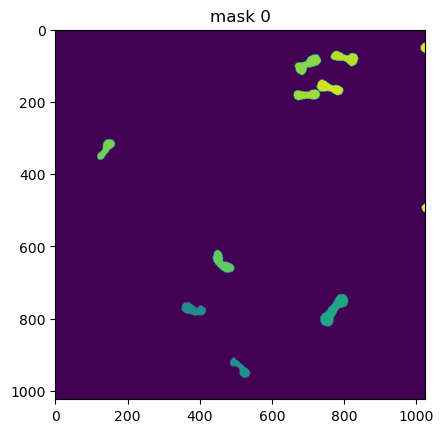

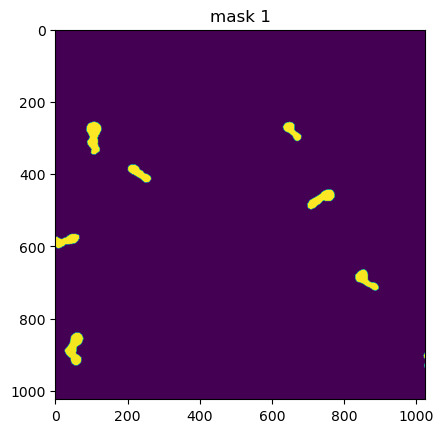

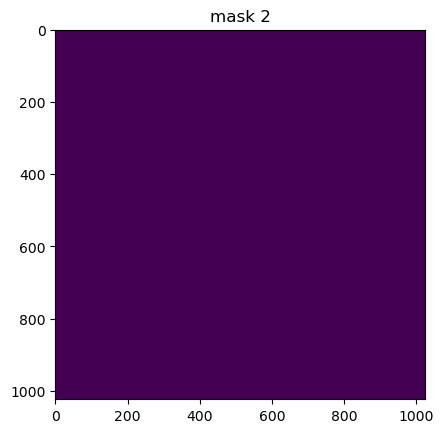

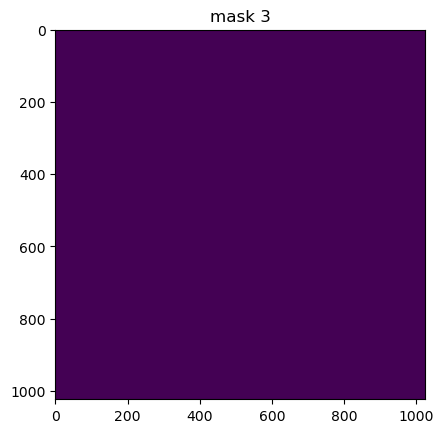

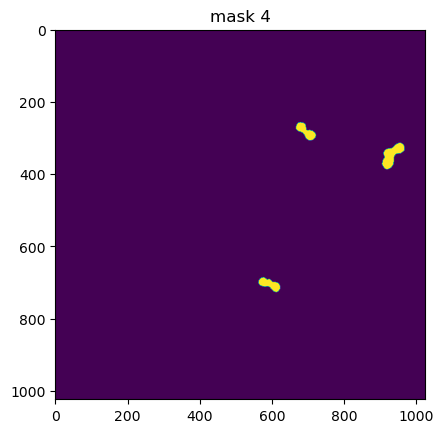

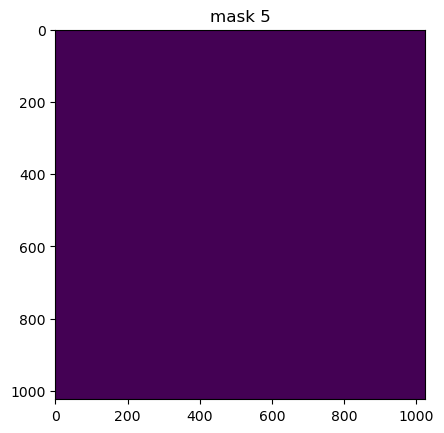

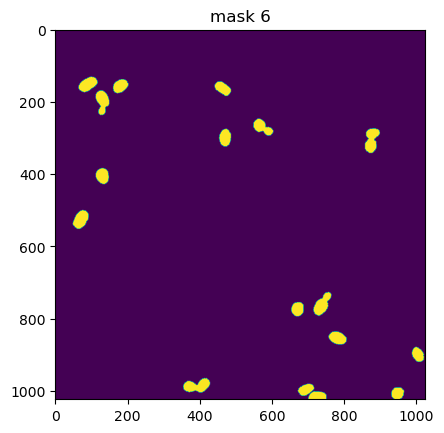

made  7 mask channels


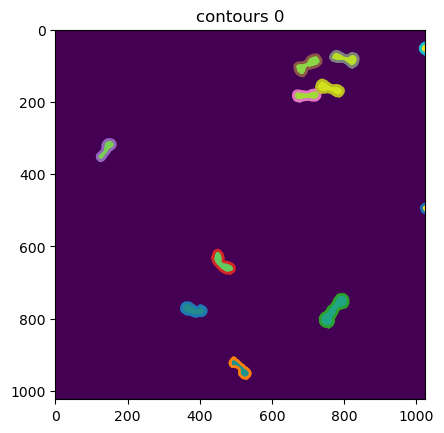

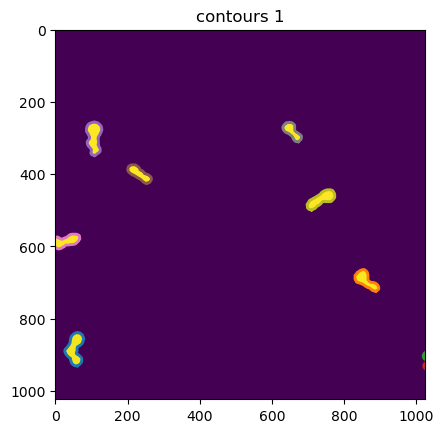

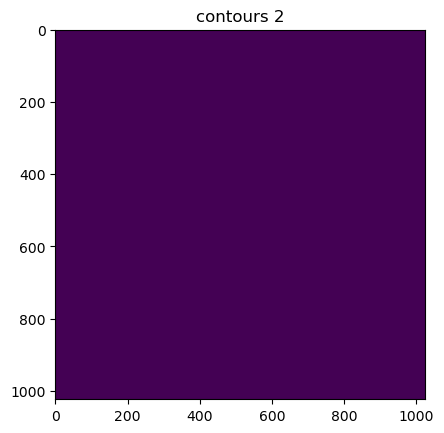

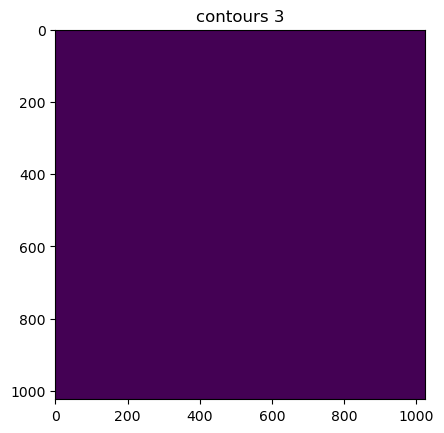

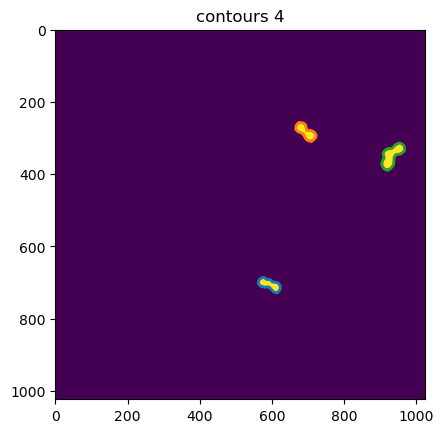

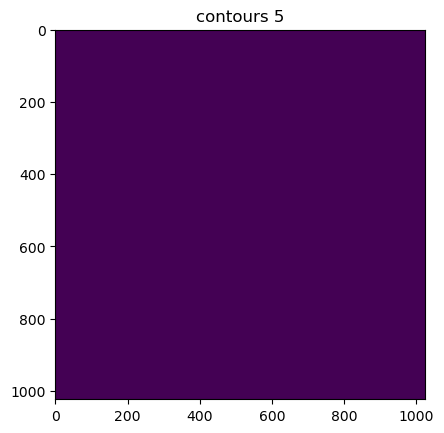

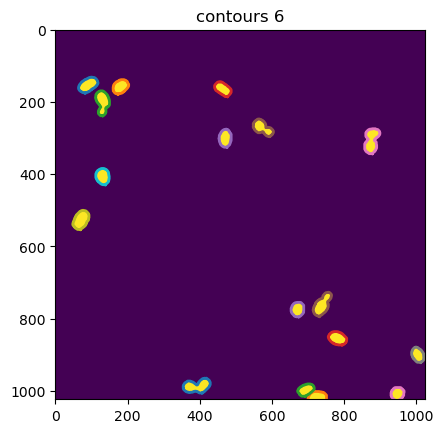

  Saved mask polygons to: new40x/P1_1G7-08_mask_poly.txt
  Saved image to: ./datasets/train/images/P1_1G7-08_24.png
  Saved label to: ./datasets/train/labels/P1_1G7-08_24.txt

Processing: new40x/P1_1G7-18.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new40x/P1_1G7-18.czi
  Image shape: (2120, 2208, 3)
  Detected 3 channels (3D format)
  Channel shapes: []
  Found mask in group 'FOV0', frame 'T0'
  Unique mask values: [   0    7    8    9   16   34   35   36   37   38   39   40   41   42
 1002 1007 1017 1018 1019 1020 1021 2006 2007 2009 4002 4008 4009 4010
 6003 6006 6041 6042 6043 6044 6045 6046 6048 6049 6050 6051 6052 6053
 6054 6055 6056 6057 6058]
  Saved mask polygons to: new40x/P1_1G7-18_mask_poly.txt
  Saved image to: ./datasets/train/images/P1_1G7-18_25.png
  Saved label to: ./datasets/train/labels/P1_1G7-18_25.txt

Processing: new40x/P1_2B2-03.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new40x/P1_2B2-03.czi
  Image s

In [14]:
# Load and process CZI images from new40x folder
import glob
import cv2
import numpy as np
import h5py
from PIL import Image
import os
import tqdm
import matplotlib.pyplot as plt
import PIL.Image as Image

# Get CZI files from new40x folder
czi_files = glob.glob('new40x/*.czi')
czi_files = sorted(czi_files)
print(f"Found {len(czi_files)} CZI files in new40x folder")

# Initialize imagej if not already initialized
if 'ij' not in globals():
	import imagej
	ij = imagej.init('sc.fiji:fiji', headless=True)
	print("Initialized ImageJ")

# Process each CZI file
for i, czi_file in enumerate(czi_files):
	print(f"\nProcessing: {czi_file}")
	
	# Check if corresponding mask file exists
	mask_file = czi_file.replace('.czi', '_mask.h5')
	if not os.path.exists(mask_file):
		print(f"  Warning: No mask file found for {czi_file}, skipping...")
		continue
	
	# Load CZI file using ImageJ
	dataset_ij = ij.io().open(czi_file)
	img5d = ij.py.from_java(dataset_ij)
	
	print(f"  Image shape: {img5d.shape}")
	
	# Extract channels (assuming format is [T, C, Z, Y, X] or [C, Z, Y, X])
	# Adjust indices based on actual shape

	num_channels = img5d.shape[2]
	channels = []
	print(f"  Detected {num_channels} channels (3D format)")
	# Select first timepoint and Z-slice
	plane = np.array(img5d)
	
	# Normalize to 0-255 uint8
	plane = plane.astype(np.float32)
	plane -= plane.min()
	plane /= plane.max()
	plane_uint8 = (plane * 255).astype(np.uint8)
	
	# Crop to 1024x1024 if larger
	crop_size = 1024
	if plane_uint8.shape[0] > crop_size or plane_uint8.shape[1] > crop_size:
		plane_uint8 = plane_uint8[:crop_size, :crop_size]
	else:
		# Pad with zeros if smaller
		pad_y = max(0, crop_size - plane_uint8.shape[0])
		pad_x = max(0, crop_size - plane_uint8.shape[1])
		plane_uint8 = np.pad(plane_uint8, ((0, pad_y), (0, pad_x)), mode='constant', constant_values=0)
	
	pil_img = Image.fromarray(plane_uint8)
	print(f"  Channel shapes: {[ch.shape for ch in channels[:3]]}")	
	# Load and process mask
	maskh5 = h5py.File(mask_file, 'r')
	mask = None
	for group in maskh5.keys():
		for frame in maskh5[group]:
			mask_data = np.array(maskh5[group][frame], dtype=np.uint16)
			if np.sum(mask_data) > 0:
				mask = mask_data[:crop_size, :crop_size]
				print(f"  Found mask in group '{group}', frame '{frame}'")
				print(f"  Unique mask values: {np.unique(mask)}")
				break
		if mask is not None:
			break
	
	if mask is None:
		print(f"  Warning: No valid mask found in {mask_file}, skipping...")
		maskh5.close()
		continue
	
	# Convert mask to contour file
	mask_poly_file = czi_file.replace('.czi', '_mask_poly.txt')
	verbose = True if i < 3 else False
	mask_poly_file = mask2contourfile(mask, mask_poly_file, verbose=verbose)
	print(f"  Saved mask polygons to: {mask_poly_file}")
	
	# Determine which split to add to (80% train, 10% val, 10% test)
	import random
	rand_val = random.random()
	if rand_val < 0.8:
		split = 'train'
	elif rand_val < 0.9:
		split = 'val'
	else:
		split = 'test'
	
	# Save stacked image as PNG
	base_name = os.path.basename(czi_file).replace('.czi', '')

	# Convert to PIL image
	pil_img = Image.fromarray(plane_uint8)
	# Convert to RGB
	rgb_img = pil_img.convert('RGB')

	png_path = f'./datasets/{split}/images/{base_name}_{count}.png'
	rgb_img.save(png_path)
	print(f"  Saved image to: {png_path}")
	
	# Copy mask file
	label_path = f'./datasets/{split}/labels/{base_name}_{count}.txt'
	import shutil
	shutil.copyfile(mask_poly_file, label_path)
	print(f"  Saved label to: {label_path}")
	
	count += 1
	maskh5.close()

print(f"\n\nTotal images processed: {count}")
print(f"CZI images from new40x folder have been added to the dataset")

In [15]:
from sklearn.preprocessing import RobustScaler
import numpy as np
import pickle


# Initialize the RobustScaler
scaler_bf = RobustScaler()

images_bf = np.stack([ dataset[sample]['stack_mat'][frame] for sample in dataset for frame in dataset[sample]['stack_mat'] ])
print('stacks' , images_bf.shape)

image_stack_bf = images_bf.reshape(-1, images_bf.shape[0])

print( 'fitting scalers ' ) 
scaler_bf.fit(image_stack_bf)

scalers = [scaler_bf]
print('scalers', scaler_bf.center_ , scaler_bf.scale_ , len(scaler_bf.center_) , len(scaler_bf.scale_) )
with open('scalers.pkl' , 'wb') as scalerdump:
	scalerdump.write(pickle.dumps(scalers))

stacks (88, 1024, 1024, 3)
fitting scalers 
scalers [33.2247557  33.23917015 33.2247557  33.26086957 33.2183908  33.22727273
 33.26086957 33.26086957 33.26086957 33.22183099 33.2247557  33.26086957
 33.22183099 33.22183099 33.26086957 33.26086957 33.22183099 33.22183099
 33.2247557  33.26086957 33.22183099 33.23828921 33.26086957 33.26086957
 33.22727273 33.2247557  33.22727273 33.26086957 33.2183908  33.22183099
 33.28539823 33.25100134 33.22183099 33.22727273 33.2183908  33.26086957
 33.2183908  33.22183099 33.27043347 33.26086957 33.23828921 33.2418041
 33.22183099 33.26086957 33.22183099 33.22727273 33.26086957 33.26086957
 33.22727273 33.22727273 33.22183099 33.26086957 33.22183099 33.22183099
 33.26086957 33.26086957 33.25100134 33.22183099 33.2247557  33.26086957
 33.2183908  33.2247557  33.26086957 33.23828921 33.22183099 33.2247557
 33.22727273 33.26086957 33.22183099 33.22183099 33.26086957 33.23828921
 33.22727273 33.2247557  33.22183099 33.26086957 33.22183099 33.22727273
 

In [16]:
#apply data augmentation
#image augmentation for training

import cv2
import random
import numpy as np

def random_rotation(image, masks, angle_range):
	angle = random.uniform(-angle_range, angle_range)
	image =  Image.fromarray(  np.array( np.ones(image.shape)*256 - Image.fromarray(image)).astype(np.uint8) )
	image = image.rotate(angle)
	masks = [ Image.fromarray(m) for m in masks ]
	masks = [ m.rotate(angle) for m in masks ]
	return np.array(image), masks

def random_flip(image, masks):
	if random.random() > 0.5:
		image = cv2.flip(image, 1)
		masks = [ cv2.flip(np.array(m), 1) for m in masks]
	return image, masks

def random_augmentation(image, masks, angle_range, crop_size):
	
	image, masks = random_rotation(image, masks, angle_range)
	
	image, masks = random_flip(image, masks)
   
	
	#image, mask = random_crop(image, mask, crop_size)
	return image, masks

#resize to original size
def resize(image, mask, size):
	image = cv2.resize(image, size)
	mask = cv2.resize(mask, size)
	return image, mask

#apply augmentation and then resize to original size
def augment_and_resize(image, masks, angle_range=180, crop_size=900, size=[1024,1024]):
	image = image.astype(np.uint8)
	image, masks = random_augmentation(image, masks, angle_range, crop_size)
	masks = [np.array(m) for m in masks ]
	#image, masks = resize(image, masks, size)
	return image, masks

In [17]:

augmented_folder = 'augmented/'

In [18]:
import shutil
overwite = True
if overwite:
	try:
		shutil.rmtree(augmented_folder)
	except:
		pass
	os.mkdir(augmented_folder)
	os.mkdir(augmented_folder+'train')
	os.mkdir(augmented_folder+'train/images/')
	os.mkdir(augmented_folder+'train/labels/')
	os.mkdir(augmented_folder +'test')
	os.mkdir(augmented_folder+'test/images/')
	os.mkdir(augmented_folder + 'test/labels/')
	os.mkdir(augmented_folder +'val/')
	os.mkdir(augmented_folder +'val/images')
	os.mkdir(augmented_folder + 'val/labels')


In [19]:
verbose = False
import tqdm 
x_augment = 10
augmented = {}
count = 0
for sample in tqdm.tqdm(dataset):
	augmented[sample] ={}
	mask = dataset[sample]['maskmatrix']
	masks = split_mask(mask)
	for frame in dataset[sample]['stack_mat']:
		image = dataset[sample]['stack_mat'][frame]	
		for i in range(x_augment):
			img , masks = augment_and_resize(image,masks)
			
			for m in masks:
				m[m>0] = 1
				
			if count < 10 and verbose == True:
				plt.imshow( img[:,:,0] , cmap = 'Greys')
				plt.colorbar( location = 'left')
				plt.show()
			augmented[sample]['mask'] = mask
			img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

			cv2.imwrite(augmented_folder+'train/images/img_'+str(count)+'.png', img )
			augmented[sample]['img'] = augmented_folder+'train/images/img_'+str(count)+'.png'
			
			lines = None
			for i,m in enumerate(masks):
				if lines is None:
					lines = output_contours(m, i , verbose = verbose)
				else:
					lines += output_contours(m, i , verbose = verbose)
			with open(augmented_folder + 'train/labels/img_'+ str(count)+ '.txt', 'w') as f:
				for l in lines:
					f.write(l)
			augmented[sample]['mask_poly'] = augmented_folder  +'train/labels/img_'+ str(count)+ '.txt'
			#add polygons
			count+=1

			
			

100%|██████████| 22/22 [06:50<00:00, 18.65s/it]


In [20]:
#move a fraction of the training data and corresponding labels to val
import random
import shutil
import os

datasetdir = 'datasets/'#augmented_folder

files = os.listdir(datasetdir +'train/images/')
print(files[0:100], '...')
random.shuffle(files)
val_files = files[:int(len(files)*.1)]
for f in val_files:
	shutil.move(datasetdir + 'train/images/'+f, datasetdir+'val/images/'+f)
	shutil.move(datasetdir +'train/labels/'+f.replace('.png', '.txt'), datasetdir + 'val/labels/'+f.replace('.png', '.txt'))

	
files = os.listdir(datasetdir+'train/images/')
random.shuffle(files)

test_files = files[:int(len(files)*.1)]
for f in test_files:
	shutil.move(datasetdir + 'train/images/'+f, datasetdir + 'test/images/'+f)
	shutil.move(datasetdir + 'train/labels/'+f.replace('.png', '.txt'), datasetdir + 'test/labels/'+f.replace('.png', '.txt'))

['img_1.png', 'img_12.png', 'img_0.png', 'img_6.png', 'img_8.png', 'img_17.png', 'P1_1G7-08_24.png', 'img_19.png', 'P1_1E3-13_22.png', 'P1_1G2-09_23.png', 'img_3.png', 'img_10.png', 'img_15.png', 'img_18.png', 'img_4.png', 'img_9.png', 'img_13.png', 'img_16.png', 'P1_1G7-18_25.png', 'img_5.png', 'img_21.png', 'img_2.png', 'img_14.png', 'img_11.png', 'img_7.png', 'img_20.png'] ...


In [21]:
#create traininging yaml file for the dataset
outyaml = """
train: datasets/train
val: datasets/val
test: datasets/test

names: 
 0: f
 1: h
 2: lmcf
 3: lmsgfp
 4: lsgfp
 5: dip
 6: d2
 

# Hyperparameters
# lr0: 0.01  # initial learning rate (i.e. SGD=1E-2, Adam=1E-3)
# lrf: 0.01  # final learning rate (lr0 * lrf)
# momentum: 0.937  # SGD momentum/Adam beta1
# weight_decay: 0.0005  # optimizer weight decay 5e-4
# warmup_epochs: 3.0  # warmup epochs (fractions ok)
# warmup_momentum: 0.8  # warmup initial momentum
# warmup_bias_lr: 0.1  # warmup initial bias lr
# box: 7.5  # box loss gain
# cls: 0.5  # cls loss gain (scale with pixels)
# dfl: 1.5  # dfl loss gain
# pose: 12.0  # pose loss gain
# kobj: 1.0  # keypoint obj loss gain
# label_smoothing: 0.0  # label smoothing (fraction)
# nbs: 64  # nominal batch size
# hsv_h: 0.015  # image HSV-Hue augmentation (fraction)
# hsv_s: 0.7  # image HSV-Saturation augmentation (fraction)
# hsv_v: 0.4  # image HSV-Value augmentation (fraction)
# degrees: 0.0  # image rotation (+/- deg)
translate: 0.1  # image translation (+/- fraction)
scale: 0.2  # image scale (+/- gain)
shear: 0.2  # image shear (+/- deg) from -0.5 to 0.5
perspective: 0.1  # image perspective (+/- fraction), range 0-0.001
flipud: 0.7  # image flip up-down (probability)
fliplr: 0.5  # image flip left-right (probability)
mosaic: 0.3  # image mosaic (probability)
mixup: 0.0  # image mixup (probability)
copy_paste: 0.1  # segment copy-paste (probability)
"""

with open('./dataset.yaml', 'w') as f:
	f.write(outyaml)

In [22]:
print( open('./dataset.yaml').read() )


train: datasets/train
val: datasets/val
test: datasets/test

names: 
 0: f
 1: h
 2: lmcf
 3: lmsgfp
 4: lsgfp
 5: dip
 6: d2
 

# Hyperparameters
# lr0: 0.01  # initial learning rate (i.e. SGD=1E-2, Adam=1E-3)
# lrf: 0.01  # final learning rate (lr0 * lrf)
# momentum: 0.937  # SGD momentum/Adam beta1
# weight_decay: 0.0005  # optimizer weight decay 5e-4
# warmup_epochs: 3.0  # warmup epochs (fractions ok)
# warmup_momentum: 0.8  # warmup initial momentum
# warmup_bias_lr: 0.1  # warmup initial bias lr
# box: 7.5  # box loss gain
# cls: 0.5  # cls loss gain (scale with pixels)
# dfl: 1.5  # dfl loss gain
# pose: 12.0  # pose loss gain
# kobj: 1.0  # keypoint obj loss gain
# label_smoothing: 0.0  # label smoothing (fraction)
# nbs: 64  # nominal batch size
# hsv_h: 0.015  # image HSV-Hue augmentation (fraction)
# hsv_s: 0.7  # image HSV-Saturation augmentation (fraction)
# hsv_v: 0.4  # image HSV-Value augmentation (fraction)
# degrees: 0.0  # image rotation (+/- deg)
translate: 0.1  #

In [23]:
hyp = {}

hyp['lr0']= 0.001 # initial learning rate (i.e. SGD=1E-2, Adam=1E-3)
hyp['lrf']= 0.0001 # final learning rate (lr0 * lrf)
hyp['optimizer'] = 'Adam' # optimizer choice: 'SGD' or 'Adam'
hyp['momentum']= 0.5 # SGD momentum/Adam beta1
hyp['weight_decay']= 0.0001 # optimizer weight decay 5e-4
hyp['warmup_epochs']= 3.0 # warmup epochs (fractions ok)
hyp['warmup_momentum']= 0.8 # warmup initial momentum
hyp['warmup_bias_lr']= 0.01 # warmup initial bias lr
hyp['box']= 10 # box loss gain
hyp['cls']= 5 # cls loss gain (scale with pixels)
hyp['dfl']= .5 # dfl loss gain
hyp['pose']= 0 # pose loss gain
hyp['kobj']= 0 # keypoint obj loss gain
hyp['label_smoothing']= 0.0 # label smoothing (fraction)
hyp['nbs']= 64 # nominal batch size
hyp['hsv_h']= 0.01 # image HSV-Hue augmentation (fraction)
hyp['hsv_s']= 0.01 # image HSV-Saturation augmentation (fraction)
hyp['hsv_v']= 0.01 # image HSV-Value augmentation (fraction)
hyp['degrees']= 180.0 # image rotation (+/- deg)
hyp['translate']= 0.1 # image translation (+/- fraction)
hyp['scale']= 0.1 # image scale (+/- gain)
hyp['shear']= 0.1 # image shear (+/- deg)
hyp['perspective']= 0.1 # image perspective (+/- fraction), range 0-0.001
hyp['flipud']= 0.5 # image flip up-down (probability)
hyp['fliplr']= 0.5 # image flip left-right (probability)
hyp['mosaic']= 0.0 # image mosaic (probability)
hyp['mixup']= 0.0 # image mixup (probability)
hyp['copy_paste']= 0.0 # segment copy-paste (probability)



In [24]:
from ultralytics import YOLO
#modelpath = 'yolov8n-seg_yfusion.pt'
modelpath = 'yolov8n-seg_yfusion.pt'

import os
overwrite = True
if os.path.exists(modelpath) and overwrite == False:
	model = YOLO(modelpath)
else:
	#clear model cache if exists
	import shutil
	try:
		shutil.rmtree('./runs/')
	except:
		pass
	#train the model
	model = YOLO("yolov8n-seg.pt")
print('training model')
print(model)

training model
YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=Tru

In [26]:
train = True
if train == True:
	results = model.train(
			batch=8,
			device=1,
			data='./dataset.yaml',
			epochs=500,
			imgsz=1024,
			** hyp
		)

New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.7 🚀 Python-3.9.23 torch-2.8.0+cu128 CUDA:1 (NVIDIA RTX PRO 4000 Blackwell, 23985MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=10, cache=False, cfg=None, classes=None, close_mosaic=10, cls=5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset.yaml, degrees=180.0, deterministic=True, device=1, dfl=0.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.01, hsv_v=0.01, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=0, line_width=None, lr0=0.001, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-s

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 23.42 GiB of which 1.81 MiB is free. Process 51001 has 23.07 GiB memory in use. Including non-PyTorch memory, this process has 314.00 MiB memory in use. Of the allocated memory 31.02 MiB is allocated by PyTorch, and 16.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
#import yolo
modelpath = '/home/dmoi/projects/yeast_fusion_segmenter/runs/segment/train/weights/best.pt'
from ultralytics import YOLO
#load model and run inference
model = YOLO(modelpath)
print(model)

YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_runni

test image: datasets/test/images/P1_1G2-09_23.png

image 1/1 /home/dmoi/projects/yeast_fusion_segmenter/datasets/test/images/P1_1G2-09_23.png: 1024x1024 1 h, 13.6ms
Speed: 19.1ms preprocess, 13.6ms inference, 2.3ms postprocess per image at shape (1, 3, 1024, 1024)
{0: 'f', 1: 'h', 2: 'lmcf', 3: 'lmsgfp', 4: 'lsgfp', 5: 'dip', 6: 'd2'}
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1.], device='cuda:0')
conf: tensor([0.3442], device='cuda:0')
data: tensor([[234.1305,  23.1171, 306.9463,  79.9806,   0.3442,   1.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (1024, 1024)
shape: torch.Size([1, 6])
xywh: tensor([[270.5384,  51.5488,  72.8157,  56.8635]], device='cuda:0')
xywhn: tensor([[0.2642, 0.0503, 0.0711, 0.0555]], device='cuda:0')
xyxy: tensor([[234.1305,  23.1171, 306.9463,  79.9806]], device='cuda:0')
xyxyn: tensor([[0.2286, 0.0226, 0.2998, 0.0781]], device='cuda:0')


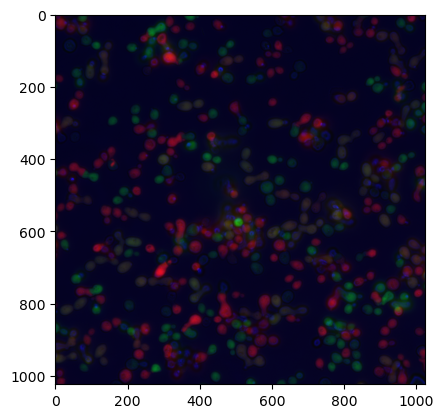

In [ ]:
import glob
test_img = 'datasets/test/images/*.png'
test_img = glob.glob(test_img)[0]
print('test image:' , test_img)
#show the image

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(test_img)
plt.imshow(img)

results = model.predict(test_img)
print(results[0].names)
print( results[0].boxes)


image 1/1 /home/dmoi/projects/yeast_fusion_segmenter/datasets/test/images/P1_1G2-09_23.png: 1024x1024 1 h, 13.6ms
Speed: 17.4ms preprocess, 13.6ms inference, 2.2ms postprocess per image at shape (1, 3, 1024, 1024)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'f', 1: 'h', 2: 'lmcf', 3: 'lmsgfp', 4: 'lsgfp', 5: 'dip', 6: 'd2'}
obb: None
orig_img: array([[[46,  7, 47],
        [54,  6, 46],
        [64,  7, 47],
        ...,
        [41,  5, 10],
        [54,  6, 10],
        [64,  6, 10]],

       [[45,  6, 46],
        [48,  7, 46],
        [55,  6, 47],
        ...,
        [42,  5,  9],
        [54,  5,  9],
        [64,  5, 10]],

       [[43,  6, 47],
        [43,  7, 48],
        [49,  7, 49],
        ...,
        [43,  5, 10],
        [55,  6, 10],
        [66,  5,  8]],

       ...,

       [[34,  3,  6],
        [38,  3,  6],
        [35,  3,  

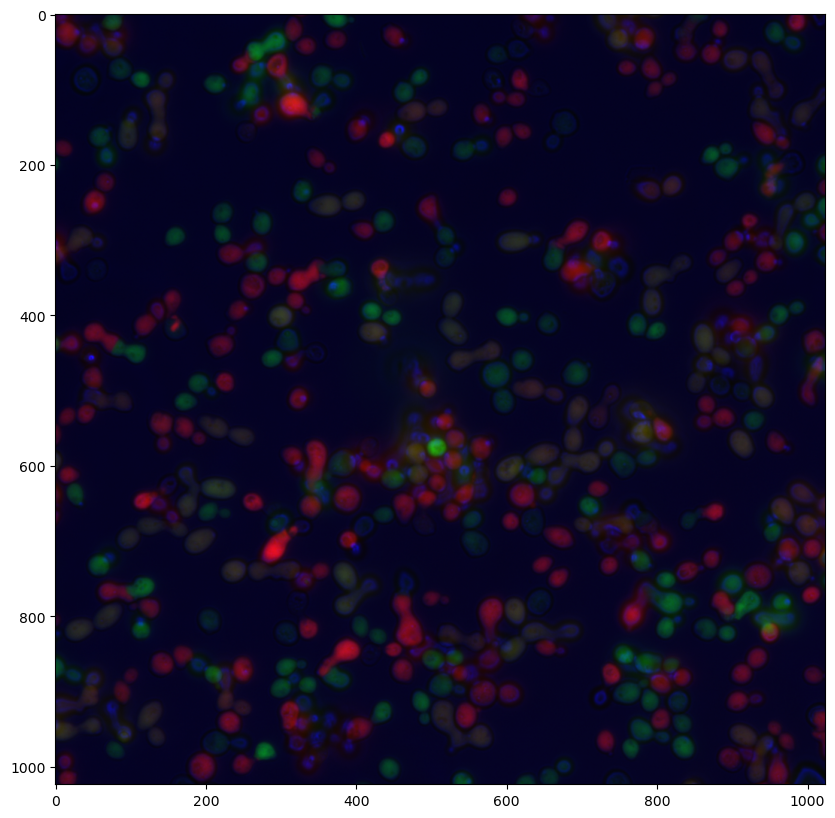

Empty DataFrame
Columns: []
Index: []
0 objects detected

image 1/1 /home/dmoi/projects/yeast_fusion_segmenter/datasets/test/images/P1_2B2-03_26.png: 1024x1024 (no detections), 14.4ms
Speed: 4.3ms preprocess, 14.4ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'f', 1: 'h', 2: 'lmcf', 3: 'lmsgfp', 4: 'lsgfp', 5: 'dip', 6: 'd2'}
obb: None
orig_img: array([[[33,  3,  0],
        [34,  2,  1],
        [33,  2,  1],
        ...,
        [32,  4,  2],
        [30,  3,  2],
        [30,  3,  2]],

       [[34,  2,  1],
        [34,  2,  1],
        [34,  3,  1],
        ...,
        [29,  4,  2],
        [31,  4,  2],
        [31,  3,  2]],

       [[33,  2,  1],
        [34,  2,  1],
        [34,  2,  1],
        ...,
        [30,  3,  2],
        [31,  3,  2],
        [31,  4,  2]],

       ...,

       [[36,  4,  3],
       

AttributeError: 'NoneType' object has no attribute 'cpu'

In [ ]:
#use model to predict
import numpy as np
import glob
from scipy.stats import describe
import pandas as pd
import matplotlib.pyplot as plt
import colour as clr

def predpng(model,imgfile , outcsv , savefig = True):
	results = model(imgfile ,imgsz=1024 ,  visualize=False)
	print(results[0])
	classes = results[0].names
	nboxes = len(results[0].boxes)
	proba = results[0].boxes.conf.cpu().numpy()
	xywh = results[0].boxes.xyxy.cpu().numpy()
	masks = results[0].masks.cpu().numpy()
	plt.figure(figsize=(10,10))

	#output the results
	red = clr.Color("red")
	lime = clr.Color("lime")
	colors = [c.hex_l for c in list(red.range_to(lime, len(classes)))]
	colors = { c:colors[i] for i,c in enumerate(classes) }
	nclasses = { int(k):k for k in classes.keys() }
	img = Image.open(imgfile)
	img = np.array(img)
	plt.imshow(img)
	resdict = {}
	rescount = 0
	for i in range(nboxes):
		#iterate over the detected objects
		c = int(results[0].boxes.cls[i])
		if proba[i] > 0.5:
			x1,y1,x2,y2 = xywh[i]
			c = int(c)
			plt.plot([x1,x2,x2,x1,x1], [y1,y1,y2,y2,y1], color = colors[c], linewidth = 2)
			#only two decimal places
			label = str(c) + ' ' + str(proba[i])[:4]
			plt.text(x1, y1, label, color = colors[c])
			mask = masks[i].numpy().to('cpu').xy[0]
			mask = mask.astype(int)
			# Resize mask to the original image size if necessary            
			bf = img[mask , 0].ravel()
			rfp = img[mask , 1].ravel()
			gfp = img[mask , 2].ravel()
			bf_stats = describe(bf)
			rfp_stats = describe(rfp)
			gfp_stats = describe(gfp)
			#create a dictionary with the results
			bf_stats = { 'bf_mean': bf_stats.mean, 'bf_std': bf_stats.variance, 'bf_min': bf_stats.minmax[0], 'bf_max': bf_stats.minmax[1] , 'bf_skew': bf_stats.skewness }
			rfp_stats = { 'rfp_mean': rfp_stats.mean, 'rfp_std': rfp_stats.variance, 'rfp_min': rfp_stats.minmax[0], 'rfp_max': rfp_stats.minmax[1]  , 'rfp_skew': rfp_stats.skewness }
			gfp_stats = { 'gfp_mean': gfp_stats.mean, 'gfp_std': gfp_stats.variance, 'gfp_min': gfp_stats.minmax[0], 'gfp_max': gfp_stats.minmax[1]  , 'gfp_skew': gfp_stats.skewness }
			resdict[rescount] = { 'class': c, 'proba': proba[i], 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2   }
			resdict[rescount].update(bf_stats)
			resdict[rescount].update(rfp_stats)
			resdict[rescount].update(gfp_stats)
			rescount += 1
	
	#add legend
	if savefig == True:
		plt.savefig(imgfile.replace('.png', '_pred.png'))
	else:
		plt.show()

	plt.clf()
	plt.close()
	#output to csv
	df = pd.DataFrame.from_dict(resdict , orient= 'index')
	print(df)
	print(len(df), 'objects detected')
	df.to_csv(outcsv)

for imgfile in glob.glob('datasets/test/images/*.png'):
	predpng(model, imgfile , imgfile.replace('.png', '.csv') , savefig = False)


In [ ]:
import glob
import shutil

folders = glob.glob('manual_test/*/')
dataset = {}
for folder in folders:
	dataset[folder] = { 'bf': glob.glob(folder + '/BF*.tif') }
	dataset[folder]['gfp'] = glob.glob(folder + '/GFP*.tif')
	dataset[folder]['rfp'] = glob.glob(folder + '/RFP*.tif')
count = 0
for sample in dataset:
	print('loading img')
	img = Image.open(dataset[sample]['bf'][0])
	img = [frame for frame in yield_frames(img,scaler = True , verbose=verbose)]
	print('loading gfp')
	gfp = Image.open(dataset[sample]['gfp'][0])
	gfp = [frame for frame in yield_frames(gfp,scaler = True,verbose=verbose)]
	print('loading rfp')
	rfp = Image.open(dataset[sample]['rfp'][0])
	rfp = [frame for frame in yield_frames(rfp,scaler = True,verbose=verbose)]
	dataset[sample]['stack']= []
	#stack the frames together
	for i in tqdm.tqdm(range(len(img))):
		im = np.stack([img[i], gfp[i], rfp[i]], axis=-1)
		#dataset[sample]['stack_mat'][i] = im
		#im = cv2.cvtColor(im, cv2.COLOR_RGB2BGR)
		print(sample+'img_'+str(count)+'.png')
		cv2.imwrite(sample+'img_'+str(count)+'.png', im )
		#adjust_brightness_contrast('./datasets/train/images/img_'+str(count)+'.png','./datasets/train/images/img_'+str(count)+'.png')
		dataset[sample]['stack'].append(sample+'img_'+str(count)+'.png')
		count += 1
print(dataset)


{}


In [ ]:
print(dataset)

{}


In [ ]:
for sample in dataset:
	print(sample)
	for img in dataset[sample]['stack']:
		print(img)
		
		predpng(model, img , img.replace('.png', '.csv'))

In [ ]:
cd /home/dmoi/projects/yeast_fusion_segmenter/

/home/dmoi/projects/yeast_fusion_segmenter


In [ ]:
#open czi images
import numpy as np
import matplotlib.pyplot as plt
import glob

new_images = glob.glob('new_images/*/*.czi')
print(new_images)

['new_images/filtro H/5-05.czi', 'new_images/filtro H/5-06.czi', 'new_images/filtro H/5-03.czi', 'new_images/filtro H/5-04.czi', 'new_images/filtro Ph1/5-01.czi', 'new_images/filtro Ph1/5-02.czi', 'new_images/filtro Ph1/5-05.czi', 'new_images/filtro Ph1/5-07.czi', 'new_images/filtro Ph1/5-03.czi', 'new_images/filtro Ph1/5-04.czi']


In [ ]:
import imagej
import numpy as np
from PIL import Image
# 1. Initialize ImageJ (this will download a minimal Fiji if needed)
#    You can specify a local Fiji install by passing the path instead of 'sc.fiji:fiji'
ij = imagej.init('sc.fiji:fiji', headless=True)

The headless flag of imagej.init is deprecated. Use the mode argument instead.


The headless flag of imagej.init is deprecated. Use the mode argument instead.


ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new_images/filtro H/5-05.czi


Operating in headless mode - the original ImageJ will have limited functionality.


(2120, 2208, 3)


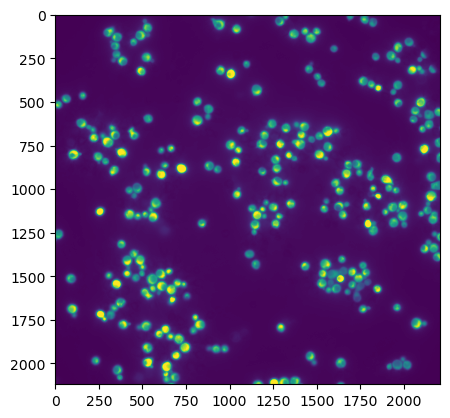

In [ ]:
import imagej
import numpy as np
from PIL import Image

# 1. Initialize ImageJ (this will download a minimal Fiji if needed)
#    You can specify a local Fiji install by passing the path instead of 'sc.fiji:fiji'
ij = imagej.init('sc.fiji:fiji', headless=True)

# 2. Open your CZI file
dataset = ij.io().open(new_images[0])

# 3. Convert the ImageJ Dataset to a NumPy array
#    This gives an array of shape (T, C, Z, Y, X)
img5d = ij.py.from_java(dataset)

print( img5d.shape)
# 4. Select the plane(s) you need.
#    e.g. first timepoint, first channel, first Z‑slice:
plane = np.array(img5d[:,:,0])

# 5. Normalize to 0–255 uint8
plane = plane.astype(np.float32)
plane -= plane.min()
plane /= plane.max()
plane_uint8 = (plane * 255).astype(np.uint8)
#show image
plt.imshow(plane_uint8)
plt.show()


# 6. (Optional) Resize / convert to RGB to match your model’s input
pil_img = Image.fromarray(plane_uint8).resize((256, 256))
rgb_img = pil_img.convert('RGB')

# 7. Final array for your network, normalized to [0,1]
input_array = np.array(rgb_img).astype(np.float32) / 255.0

In [ ]:
from scipy.ndimage import zoom as scipy_zoom


ij = imagej.init('sc.fiji:fiji', headless=True)

def load_czi_with_imagej(filepath, resize=None, ij=ij, zoom=1):
	"""
	Load a CZI file using ImageJ and convert it to a numpy array
	
	Args:
		filepath (str): Path to the CZI file
		resize (tuple): Optional tuple of (width, height) to resize the image
		
	Returns:
		tuple: (normalized_array, png_path) - Image array and path to saved PNG
	"""
	# Open the CZI file
	dataset = ij.io().open(filepath)
	
	# Convert to numpy array
	img5d = ij.py.from_java(dataset)
	
	# Select first timepoint and Z-slice
	plane = np.array(img5d)
	
	# Normalize to 0-255 uint8
	plane = plane.astype(np.float32)
	plane -= plane.min()
	plane /= plane.max()
	plane_uint8 = (plane * 255).astype(np.uint8)
	
	# Convert to PIL image
	pil_img = Image.fromarray(plane_uint8)
	
	# Resize if specified
	if resize is not None:
		pil_img = pil_img.resize(resize)
	
	# Convert to RGB
	rgb_img = pil_img.convert('RGB')
	
	# Save as PNG for YOLO predictions
	pngfile = filepath.replace('.czi', '.png').replace('.CZI', '.png')
	rgb_img.save(pngfile)
	
	# Return normalized array and PNG path
	return np.array(rgb_img).astype(np.float32) / 255.0, pngfile


def zoom_img(img, zoom_factor, target_size=1024, base_filepath=None):
	"""
	Create overlapping crops from a large image for zoomed predictions.
	
	Args:
		img: Image array (H, W, C)
		zoom_factor: Fraction of image to use for each crop (e.g., 40/60)
		target_size: Size to resize each crop to
		base_filepath: Base filepath for saving PNG crops (optional)
		
	Returns:
		tuple: (crops, png_paths, coordinates)
			- crops: List of cropped image arrays
			- png_paths: List of paths to saved PNG files
			- coordinates: List of (x1, y1, x2, y2) tuples
	"""
	# Calculate crop dimensions based on zoom factor
	y_size = int(img.shape[0] * zoom_factor)
	x_size = int(img.shape[1] * zoom_factor)
	
	crops = []
	png_paths = []
	coordinates = []
	crop_number = 0
	
	# Iterate over image with 50% overlap
	for y in range(0, img.shape[0] - y_size + 1, y_size // 2):
		for x in range(0, img.shape[1] - x_size + 1, x_size // 2):
			# Extract sub-region
			sub = img[y:y + y_size, x:x + x_size]
			
			# Resize to target size using cubic interpolation
			sub_resized = cv2.resize(sub, (target_size, target_size), 
									interpolation=cv2.INTER_CUBIC)
			
			# Convert to uint8 for saving
			sub_uint8 = (sub_resized * 255).astype(np.uint8)
			
			# Create PIL image
			sub_pil = Image.fromarray(sub_uint8)
			
			# Save as PNG
			if base_filepath:
				# Create PNG filename based on original file and crop number
				base_name = os.path.splitext(base_filepath)[0]
				png_path = f"{base_name}_crop_{crop_number}.png"
				sub_pil.save(png_path)
				png_paths.append(png_path)
			
			crops.append(sub_resized)
			coordinates.append((x, y, x + x_size, y + y_size))
			crop_number += 1
	
	return crops, png_paths, coordinates


def pred_zoomed_image(model, filepath, target_size=1024, zoom_factor=40/60):
	"""
	Run predictions on zoomed (cropped) regions of a CZI image.
	
	Args:
		model: YOLO model
		filepath: Path to CZI file
		target_size: Size for model input (default: 1024)
		zoom_factor: Zoom factor for cropping (default: 40/60)
		
	Returns:
		tuple: (all_predictions, coordinates, png_paths)
	"""
	# Load CZI image
	img, pngfile = load_czi_with_imagej(filepath)
	
	# Create zoomed crops with PNG files
	crops, png_paths, coordinates = zoom_img(img, zoom_factor, target_size, 
											  base_filepath=filepath)
	
	# Run predictions on each crop
	all_predictions = []
	for png_path in png_paths:
		prediction = model.predict(png_path, imgsz=target_size, verbose=False)
		all_predictions.append(prediction)
	
	return all_predictions, coordinates, png_paths


def pred_czi(model, filepath, ij=ij, resize=(1024, 1024), zoom_factor=40/60):
	"""
	Run prediction on full CZI image (without zooming).
	
	Args:
		model: YOLO model
		filepath: Path to CZI file
		resize: Tuple of (width, height) to resize image
		
	Returns:
		predictions: YOLO prediction results
	"""
	# Load and preprocess CZI image
	img, pngfile = load_czi_with_imagej(filepath, resize=resize, ij=ij)
	
	# Run prediction on the PNG file
	predictions = model.predict(pngfile, imgsz=1024, visualize=False)
	
	return predictions

The headless flag of imagej.init is deprecated. Use the mode argument instead.


In [ ]:
# Test the zoom_img function with PNG conversion
print("Testing zoom_img function with PNG conversion")
print(f"Using test image: {test_czi}")

# Load the CZI image
test_img, test_pngfile = load_czi_with_imagej(test_czi, resize=(2048, 2048), ij=ij)
print(f"Loaded image shape: {test_img.shape}")
print(f"PNG file saved at: {test_pngfile}")

# Create zoomed crops
zoom_factor = 40/60  # Each crop covers 2/3 of image
crops, png_paths, coordinates = zoom_img(test_img, zoom_factor, target_size=1024, 
										  base_filepath=test_czi)

print(f"\nCreated {len(crops)} zoomed crops")
print(f"Saved {len(png_paths)} PNG files")
print(f"\nFirst 5 crop coordinates (x1, y1, x2, y2):")
for i, coord in enumerate(coordinates[:5]):
	print(f"  Crop {i}: {coord}")

# Visualize a few crops
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for i in range(min(6, len(crops))):
	axs[i].imshow(crops[i])
	x1, y1, x2, y2 = coordinates[i]
	axs[i].set_title(f"Crop {i}: ({x1}, {y1}) to ({x2}, {y2})")
	axs[i].axis('off')

plt.tight_layout()
plt.show()

print(f"\nPNG files created:")
for i, path in enumerate(png_paths[:5]):
	print(f"  {i}: {path}")

Testing zoom_img function with PNG conversion


NameError: name 'test_czi' is not defined

In [ ]:
# Test pred_zoomed_image function - run predictions on all crops
print("Testing pred_zoomed_image function")
print(f"Running predictions on zoomed crops of: {test_czi}")

# Run predictions on all zoomed crops
all_predictions, coordinates, png_paths = pred_zoomed_image(
	model, 
	test_czi, 
	target_size=1024, 
	zoom_factor=40/60
)

print(f"\nRan predictions on {len(all_predictions)} crops")

# Analyze predictions from each crop
total_detections = 0
for i, (pred, coord) in enumerate(zip(all_predictions, coordinates)):
	nboxes = len(pred[0].boxes)
	total_detections += nboxes
	if nboxes > 0:
		print(f"Crop {i} at {coord}: {nboxes} detections")

print(f"\nTotal detections across all crops: {total_detections}")

# Visualize predictions on first few crops
fig, axs = plt.subplots(2, 2, figsize=(16, 16))
axs = axs.flatten()

for idx in range(len(all_predictions)):
	pred = all_predictions[idx]
	nboxes = len(pred[0].boxes)
	
	# Load the crop image
	crop_img = np.array(Image.open(png_paths[idx]))
	axs[idx].imshow(crop_img)
	
	if nboxes > 0:
		proba = pred[0].boxes.conf.cpu().numpy()
		xywh = pred[0].boxes.xyxy.cpu().numpy()
		cls_ids = pred[0].boxes.cls.cpu().numpy()
		classes = pred[0].names
		
		colors_list = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta']
		
		for i in range(nboxes):
			if proba[i] > 0.5:
				x1, y1, x2, y2 = xywh[i]
				cls_id = int(cls_ids[i])
				color = colors_list[cls_id % len(colors_list)]
				
				# Draw bounding box
				axs[idx].plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 
							 color=color, linewidth=2)
				
				# Add label
				label = f"{classes[cls_id]} {proba[i]:.2f}"
				axs[idx].text(x1, y1 - 5, label, color=color, fontsize=8,
							 bbox=dict(facecolor='white', alpha=0.7))
	
	x1, y1, x2, y2 = coordinates[idx]
	axs[idx].set_title(f"Crop {idx}: ({x1},{y1})-({x2},{y2}), {nboxes} detections")
	axs[idx].axis('off')

plt.tight_layout()
plt.show()

Testing pred_zoomed_image function


NameError: name 'test_czi' is not defined

Testing on: new_images/filtro H/5-05.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new_images/filtro H/5-05.czi


Operating in headless mode - the original ImageJ will have limited functionality.


Image shape: (1024, 1024, 3)


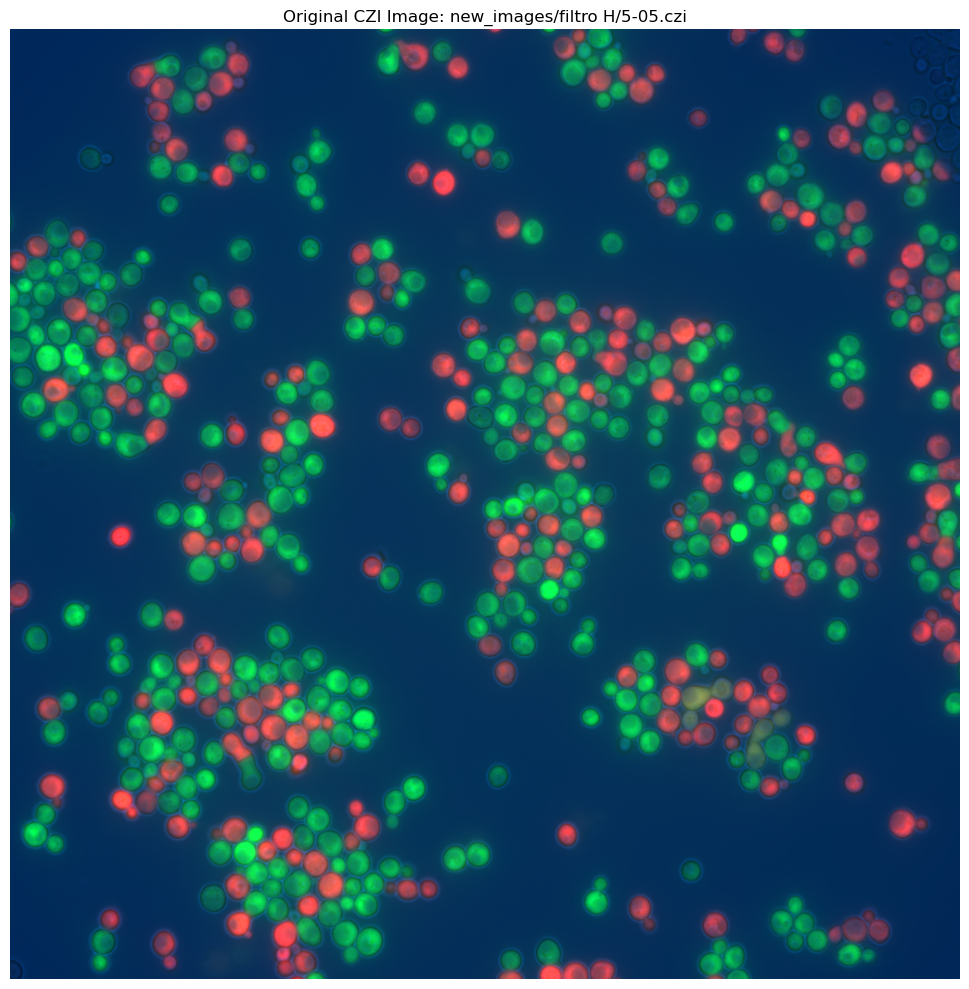

Running prediction...
Detected 9 objects


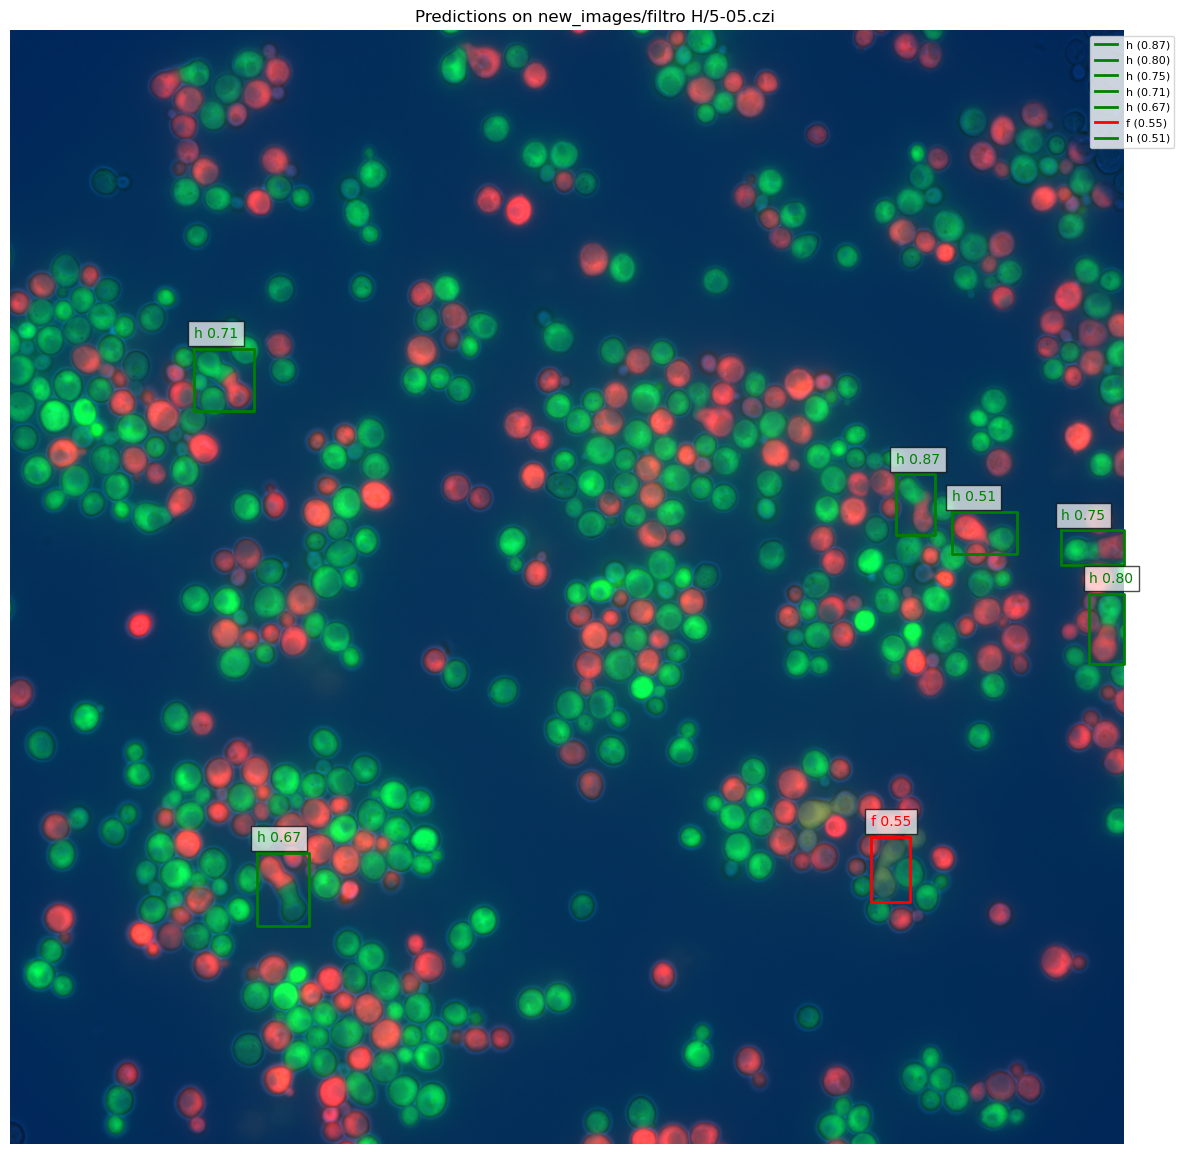


Label file saved to: new_images/filtro H/5-05_predictions.txt

Detection Summary:
Class           Confidence   Count
----------------------------------------
f               0.553        1
h               0.717        6


In [ ]:
# Test prediction on a single CZI image and create labels

# Select a CZI image for testing
test_czi = new_images[0]
print(f"Testing on: {test_czi}")

# Load and preprocess the CZI image
test_img , test_pngfile = load_czi_with_imagej(test_czi, resize=(1024, 1024), ij=ij)
print(f"Image shape: {test_img.shape}")

# Display the original image
plt.figure(figsize=(10, 10))
plt.imshow(test_img)
plt.title(f"Original CZI Image: {test_czi}")
plt.axis('off')
plt.tight_layout()
plt.show()

# Run prediction
print("Running prediction...")
results = model.predict(test_pngfile, imgsz=1024, verbose=False)

# Extract prediction results
classes = results[0].names
nboxes = len(results[0].boxes)
print(f"Detected {nboxes} objects")

if nboxes > 0:
	proba = results[0].boxes.conf.cpu().numpy()
	xywh = results[0].boxes.xyxy.cpu().numpy()
	cls_ids = results[0].boxes.cls.cpu().numpy()
	
	# Display predictions with bounding boxes
	plt.figure(figsize=(12, 12))
	img_display = (test_img * 255).astype(np.uint8)
	plt.imshow(img_display)
	
	# Define colors for visualization
	colors_list = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta']
	
	for i in range(nboxes):
		if proba[i] > 0.5:  # Only show detections above confidence threshold
			x1, y1, x2, y2 = xywh[i]
			cls_id = int(cls_ids[i])
			color = colors_list[cls_id % len(colors_list)]
			
			# Draw bounding box
			plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 
					color=color, linewidth=2, label=f"{classes[cls_id]} ({proba[i]:.2f})")
			
			# Add label text
			label = f"{classes[cls_id]} {proba[i]:.2f}"
			plt.text(x1, y1 - 10, label, color=color, fontsize=10, 
					bbox=dict(facecolor='white', alpha=0.7))
	
	plt.title(f"Predictions on {test_czi}")
	plt.axis('off')
	plt.legend(loc='upper right', fontsize=8)
	plt.tight_layout()
	plt.show()
	
	# Create YOLO format label file
	label_output = test_czi.replace('.czi', '_predictions.txt')
	with open(label_output, 'w') as f:
		for i in range(nboxes):
			if proba[i] > 0.5:
				cls_id = int(cls_ids[i])
				x1, y1, x2, y2 = xywh[i]
				
				# Convert to normalized YOLO format (center_x, center_y, width, height)
				img_height, img_width = test_img.shape[:2]
				center_x = ((x1 + x2) / 2) / img_width
				center_y = ((y1 + y2) / 2) / img_height
				width = (x2 - x1) / img_width
				height = (y2 - y1) / img_height
				
				# Write in YOLO format: class_id center_x center_y width height
				f.write(f"{cls_id} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}\n")
	
	print(f"\nLabel file saved to: {label_output}")
	
	# Print summary
	print("\nDetection Summary:")
	print(f"{'Class':<15} {'Confidence':<12} {'Count'}")
	print("-" * 40)
	for cls_id in sorted(set(cls_ids.astype(int))):
		mask = cls_ids == cls_id
		class_name = classes[cls_id]
		class_confs = proba[mask]
		count = np.sum(class_confs > 0.5)
		mean_conf = np.mean(class_confs[class_confs > 0.5]) if count > 0 else 0
		print(f"{class_name:<15} {mean_conf:<12.3f} {count}")
else:
	print("No detections found in the image")

In [ ]:
#create a visualization of cropped images from one of the zoomed images
import matplotlib.pyplot as plt
import cv2
stack,coordinates = zoom_img(plane_uint8, 40/60)
fig, axs = plt.subplots(len(stack), 1, figsize=(10, 10))
for i in range(len(stack)):
	axs[i].imshow(stack[i], cmap='gray')
	axs[i].axis('off')
plt.tight_layout()


colors = ['red', 'green', 'blue', 'yellow', 'cyan', 'magenta']
#show crops on original image
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(plane_uint8, cmap='gray')
for i, coord in enumerate(coordinates):
	x1, y1, x2, y2 = coord
	rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor=colors[i % len(colors)], facecolor='none', linewidth=2)
	ax.add_patch(rect)
ax.axis('off')
plt.tight_layout()
plt.show()

ValueError: too many values to unpack (expected 2)

In [ ]:
#predict on zoomed images
zoomed = glob.glob('./zoomed/*.czi')
for z in zoomed:
	print(z)
	plane_uint8 = load_czi_with_imagej(z, resize=None , ij=ij , zoom=1 )
	predictions = pred_zoomed_image(model, plane_uint8, target_size=1024, zoom_factor=40/60)
	print(predictions)

	#format predictions into a dataframe
	for i,pred in enumerate(predictions):
		classes = pred[0].names
		nboxes = len(pred[0].boxes)
		proba = pred[0].boxes.conf.cpu().numpy()
		xywh = pred[0].boxes.xyxy.cpu().numpy()

		print(proba)
		if pred[0].masks is not None:
			masks = pred[0].masks.cpu().numpy()

		plt.figure(figsize=(10,10))
		#output the results
		red = clr.Color("red")
		lime = clr.Color("lime")
		colors = [c.hex_l for c in list(red.range_to(lime, len(classes)))]
		colors = { c:colors[i] for i,c in enumerate(classes) }
		nclasses = { int(k):k for k in classes.keys() }
		img = Image.fromarray( stack[i] )
		img = np.array(img)
		plt.imshow(img)
		resdict = {}
		rescount = 0
		for j in range(nboxes):
			#iterate over the detected objects
			c = int(pred[0].boxes.cls[j])
			print('class', c , 'proba', proba[j])
			if proba[j] > 0.5:
				x1,y1,x2,y2 = xywh[j]
				c = int(c)
				plt.plot([x1,x2,x2,x1,x1], [y1,y1,y2,y2,y1], color = colors[c], linewidth = 2)
				#only two decimal places
				label = str(c) + ' ' + str(proba[j])[:4]
				plt.text(x1, y1, label, color = colors[c])
		plt.show()
		plt.savefig(z.replace('.czi', '_zoomedpred_'+ str(i) +'.png'))
		plt.clf()
		plt.close()

./zoomed/dprm1xdprm1-34.czi
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/./zoomed/dprm1xdprm1-34.czi


TypeError: No matching overloads found for org.scijava.io.DefaultIOService.open(tuple), options are:
	public java.lang.Object org.scijava.io.DefaultIOService.open(org.scijava.io.location.Location) throws java.io.IOException
	public java.lang.Object org.scijava.io.DefaultIOService.open(java.lang.String) throws java.io.IOException


  0%|          | 0/10 [00:00<?, ?it/s]

ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/new_images/filtro H/5-05.czi
(1024, 1024, 3)


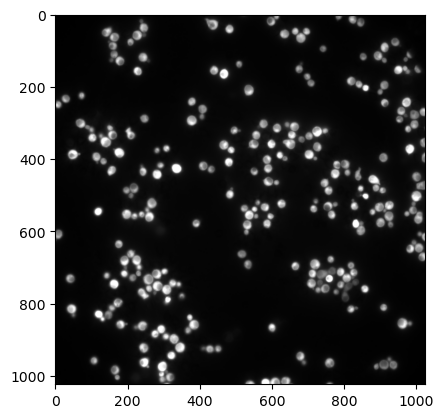

  0%|          | 0/10 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 532.00 MiB. GPU 0 has a total capacity of 23.43 GiB of which 452.12 MiB is free. Process 99071 has 22.35 GiB memory in use. Including non-PyTorch memory, this process has 610.00 MiB memory in use. Of the allocated memory 178.54 MiB is allocated by PyTorch, and 125.46 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import tqdm
import cv2

#load new czi images
for imfile in tqdm.tqdm(new_images):
	img = load_czi_with_imagej(imfile, resize=(1024,1024))
	print(img.shape)
	plt.imshow(img)
	plt.show()
	#save as png
	outfile = imfile.replace('.czi', '.png').replace('new_images', 'new_images_png')
	os.makedirs( os.path.dirname(outfile) , exist_ok= True)
	cv2.imwrite(outfile, cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2BGR) )
	#predict
	predpng(model, outfile , outfile.replace('.png', '.csv'))


In [ ]:
#load and display zoomed images and predictions
zoomed = glob.glob('zoomed/*.czi')

#load new czi images
for imfile in tqdm.tqdm(zoomed):
	img = load_czi_with_imagej(imfile, resize=(1024,1024))
	print(img.shape)
	plt.imshow(img)
	plt.show()
	#save as png
	outfile = imfile.replace('.czi', '.png').replace('zoomed', 'zoomed_png')
	os.makedirs( os.path.dirname(outfile) , exist_ok= True)
	cv2.imwrite(outfile, cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2BGR) )
	#predict
	predpng(model, outfile , outfile.replace('.png', '.csv'))

print(zoomed)
for imfile in tqdm.tqdm(zoomed):
	img = load_czi_with_imagej(imfile, resize=None)
	print(img.shape)
	plt.imshow(img)
	plt.show()
	#predict on zoomed and cropped images
	predictions = pred_zoomed_image(model, img, target_size=1024, zoom_factor=2)
	print(predictions)

  0%|          | 0/4 [00:00<?, ?it/s]

ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/zoomed/dprm1xdprm1-34.czi


  0%|          | 0/4 [00:01<?, ?it/s]


AttributeError: 'tuple' object has no attribute 'shape'

  0%|                                                                                                                                         | 0/4 [00:00<?, ?it/s]

ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/zoomed/dprm1xdprm1-34.czi
(2120, 2208, 3)


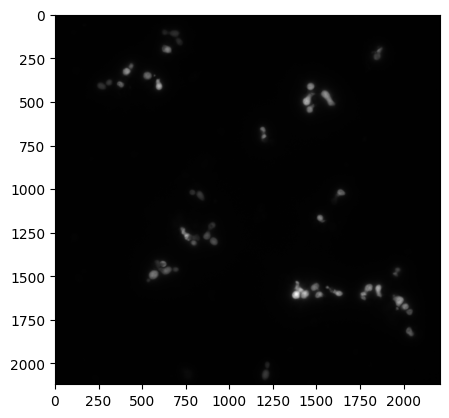

 25%|████████████████████████████████▎                                                                                                | 1/4 [00:00<00:02,  1.23it/s]

[]
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/zoomed/dprm1xdprm1-32.czi
(2120, 2208, 3)


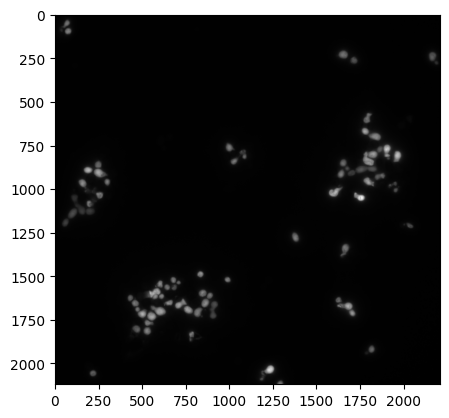

 50%|████████████████████████████████████████████████████████████████▌                                                                | 2/4 [00:01<00:01,  1.23it/s]

[]
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/zoomed/dprm1xdprm1-17.czi
(2120, 2208, 3)


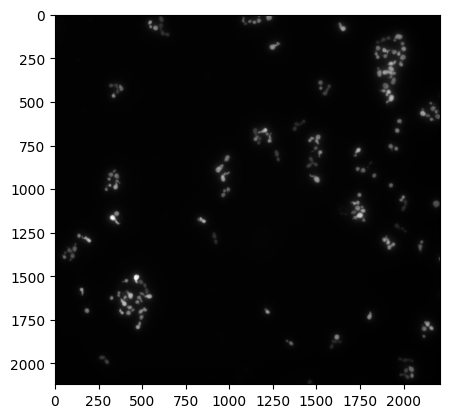

 75%|████████████████████████████████████████████████████████████████████████████████████████████████▊                                | 3/4 [00:02<00:00,  1.22it/s]

[]
ZeissCZIReader initializing /home/dmoi/projects/yeast_fusion_segmenter/zoomed/dprm1xdprm1-11.czi
(2120, 2208, 3)


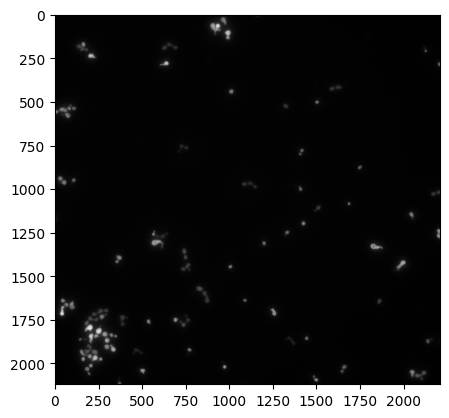

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.22it/s]

[]


In [ ]:
#apply zoom and prediction to zoomed
for imfile in tqdm.tqdm(zoomed):
	img = load_czi_with_imagej(imfile, resize=None)
	print(img.shape)
	plt.imshow(img)
	plt.show()
	#predict on zoomed and cropped images
	predictions = pred_zoomed_image(model, img, target_size=1024, zoom_factor=2)
	print(predictions)

# Pseudo-Labeling and Active Learning

This section implements advanced training strategies to improve model performance:
- **Pseudo-labeling**: Use high-confidence predictions as additional training data
- **Active learning**: Identify uncertain samples for manual annotation
- **Iterative improvement**: Combine both approaches for continuous model enhancement

In [ ]:
# Pseudo-labeling functions
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
from scipy.stats import entropy
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def calculate_prediction_uncertainty(results, method='confidence'):
	"""
	Calculate uncertainty metrics for YOLO predictions
	
	Args:
		results: YOLO prediction results
		method: 'confidence', 'entropy', or 'variance'
	
	Returns:
		float: uncertainty score (higher = more uncertain)
	"""
	if len(results[0].boxes) == 0:
		return 1.0  # Maximum uncertainty for no detections
	
	confidences = results[0].boxes.conf.cpu().numpy()
	
	if method == 'confidence':
		# Use inverse of max confidence as uncertainty
		return 1.0 - np.max(confidences)
	
	elif method == 'entropy':
		# Calculate entropy of confidence distribution
		# Normalize confidences to create probability distribution
		probs = confidences / np.sum(confidences)
		return entropy(probs)
	
	elif method == 'variance':
		# Use variance of confidences
		return np.var(confidences)
	
	else:
		raise ValueError(f"Unknown uncertainty method: {method}")

def filter_high_confidence_predictions(image_paths, model, confidence_threshold=0.8, min_detections=1):
	"""
	Filter images with high-confidence predictions for pseudo-labeling
	
	Args:
		image_paths: List of image file paths
		model: Trained YOLO model
		confidence_threshold: Minimum confidence for pseudo-labels
		min_detections: Minimum number of detections required
	
	Returns:
		List of (image_path, results) tuples for high-confidence predictions
	"""
	high_confidence_data = []
	
	for img_path in tqdm.tqdm(image_paths, desc="Filtering high-confidence predictions"):
		results = model.predict(img_path, conf=confidence_threshold, verbose=False)
		
		if len(results[0].boxes) >= min_detections:
			# Check if all detections meet confidence threshold
			confidences = results[0].boxes.conf.cpu().numpy()
			if np.all(confidences >= confidence_threshold):
				high_confidence_data.append((img_path, results))
	
	print(f"Found {len(high_confidence_data)} high-confidence predictions out of {len(image_paths)} images")
	return high_confidence_data

def create_pseudo_label_dataset(high_confidence_data, output_dir='pseudo_labels'):
	"""
	Create a dataset from pseudo-labels for additional training
	
	Args:
		high_confidence_data: List of (image_path, results) tuples
		output_dir: Directory to save pseudo-labeled dataset
	"""
	output_path = Path(output_dir)
	images_dir = output_path / 'images'
	labels_dir = output_path / 'labels'
	
	# Create directories
	images_dir.mkdir(parents=True, exist_ok=True)
	labels_dir.mkdir(parents=True, exist_ok=True)
	
	for i, (img_path, results) in enumerate(tqdm.tqdm(high_confidence_data, desc="Creating pseudo-labels")):
		# Copy image
		img_name = f"pseudo_{i:06d}.png"
		shutil.copy(img_path, images_dir / img_name)
		
		# Create YOLO format label file
		label_path = labels_dir / f"pseudo_{i:06d}.txt"
		
		with open(label_path, 'w') as f:
			if len(results[0].boxes) > 0:
				classes = results[0].boxes.cls.cpu().numpy()
				boxes = results[0].boxes.xywhn.cpu().numpy()  # Normalized coordinates
				
				for cls, box in zip(classes, boxes):
					# YOLO format: class x_center y_center width height
					f.write(f"{int(cls)} {box[0]:.6f} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f}\n")
	
	print(f"Created pseudo-label dataset with {len(high_confidence_data)} samples in {output_dir}")
	return output_path

: 

In [ ]:
# Active learning functions
def identify_uncertain_samples(image_paths, model, uncertainty_method='confidence', top_k=20):
	"""
	Identify the most uncertain samples for active learning
	
	Args:
		image_paths: List of image file paths
		model: Trained YOLO model
		uncertainty_method: Method to calculate uncertainty
		top_k: Number of most uncertain samples to return
	
	Returns:
		List of (image_path, uncertainty_score) tuples sorted by uncertainty
	"""
	uncertainties = []
	
	for img_path in tqdm.tqdm(image_paths, desc="Calculating uncertainties"):
		results = model.predict(img_path, verbose=False)
		uncertainty = calculate_prediction_uncertainty(results, method=uncertainty_method)
		uncertainties.append((img_path, uncertainty))
	
	# Sort by uncertainty (descending)
	uncertainties.sort(key=lambda x: x[1], reverse=True)
	
	print(f"Top {top_k} most uncertain samples identified")
	return uncertainties[:top_k]

def diversity_sampling(image_paths, model, features_method='bbox', n_samples=20):
	"""
	Select diverse samples for annotation using clustering
	
	Args:
		image_paths: List of image file paths
		model: Trained YOLO model
		features_method: Method to extract features ('bbox', 'image_stats')
		n_samples: Number of diverse samples to select
	
	Returns:
		List of selected image paths
	"""
	features = []
	valid_paths = []
	
	for img_path in tqdm.tqdm(image_paths, desc="Extracting features"):
		try:
			if features_method == 'bbox':
				# Use bounding box statistics as features
				results = model.predict(img_path, verbose=False)
				if len(results[0].boxes) > 0:
					boxes = results[0].boxes.xyxy.cpu().numpy()
					confidences = results[0].boxes.conf.cpu().numpy()
					
					# Features: [num_detections, mean_area, std_area, mean_conf, std_conf]
					areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
					feature_vec = [
						len(boxes),
						np.mean(areas),
						np.std(areas) if len(areas) > 1 else 0,
						np.mean(confidences),
						np.std(confidences) if len(confidences) > 1 else 0
					]
					features.append(feature_vec)
					valid_paths.append(img_path)
					
			elif features_method == 'image_stats':
				# Use image statistics as features
				img = Image.open(img_path)
				img_array = np.array(img)
				
				if len(img_array.shape) == 3:
					# Multi-channel statistics
					feature_vec = []
					for c in range(img_array.shape[2]):
						channel = img_array[:, :, c]
						feature_vec.extend([
							np.mean(channel),
							np.std(channel),
							np.min(channel),
							np.max(channel)
						])
					features.append(feature_vec)
					valid_paths.append(img_path)
					
		except Exception as e:
			print(f"Error processing {img_path}: {e}")
			continue
	
	if len(features) < n_samples:
		print(f"Warning: Only {len(features)} valid samples found, returning all")
		return valid_paths
	
	# Perform k-means clustering
	features_array = np.array(features)
	kmeans = KMeans(n_clusters=min(n_samples, len(features)), random_state=42)
	cluster_labels = kmeans.fit_predict(features_array)
	
	# Select one sample from each cluster (closest to centroid)
	selected_paths = []
	for cluster_id in range(kmeans.n_clusters):
		cluster_indices = np.where(cluster_labels == cluster_id)[0]
		cluster_features = features_array[cluster_indices]
		cluster_center = kmeans.cluster_centers_[cluster_id]
		
		# Find closest sample to cluster center
		distances = np.linalg.norm(cluster_features - cluster_center, axis=1)
		closest_idx = cluster_indices[np.argmin(distances)]
		selected_paths.append(valid_paths[closest_idx])
	
	print(f"Selected {len(selected_paths)} diverse samples using {features_method} features")
	return selected_paths

def active_learning_selection(image_paths, model, strategy='uncertainty', n_samples=20, **kwargs):
	"""
	Select samples for active learning using different strategies
	
	Args:
		image_paths: List of image file paths
		model: Trained YOLO model
		strategy: 'uncertainty', 'diversity', or 'hybrid'
		n_samples: Number of samples to select
		**kwargs: Additional arguments for specific strategies
	
	Returns:
		List of selected image paths for annotation
	"""
	if strategy == 'uncertainty':
		uncertain_samples = identify_uncertain_samples(
			image_paths, model, 
			uncertainty_method=kwargs.get('uncertainty_method', 'confidence'),
			top_k=n_samples
		)
		return [path for path, _ in uncertain_samples]
	
	elif strategy == 'diversity':
		return diversity_sampling(
			image_paths, model,
			features_method=kwargs.get('features_method', 'bbox'),
			n_samples=n_samples
		)
	
	elif strategy == 'hybrid':
		# Combine uncertainty and diversity
		uncertain_samples = identify_uncertain_samples(
			image_paths, model,
			top_k=min(100, len(image_paths))  # Get larger pool first
		)
		uncertain_paths = [path for path, _ in uncertain_samples]
		
		# Apply diversity sampling to uncertain samples
		diverse_uncertain = diversity_sampling(
			uncertain_paths, model,
			n_samples=n_samples
		)
		return diverse_uncertain
	
	else:
		raise ValueError(f"Unknown strategy: {strategy}")

: 

In [ ]:
# Iterative training functions
def incremental_training(model, pseudo_label_dir, original_data_yaml='dataset.yaml', 
						epochs=50, lr=0.0001, save_path='model_incremental.pt'):
	"""
	Perform incremental training with pseudo-labeled data
	
	Args:
		model: Base YOLO model
		pseudo_label_dir: Directory containing pseudo-labeled data
		original_data_yaml: Path to original dataset configuration
		epochs: Number of training epochs
		lr: Learning rate for incremental training
		save_path: Path to save the updated model
	
	Returns:
		Updated model
	"""
	# Create combined dataset configuration
	combined_yaml = Path('combined_dataset.yaml')
	
	# Read original dataset config
	with open(original_data_yaml, 'r') as f:
		original_config = f.read()
	
	# Create combined config that includes both original and pseudo-labeled data
	combined_config = f"""
# Combined dataset with original + pseudo-labeled data
train: [train, {pseudo_label_dir}]
val: val
test: test

names: 
	0: f
	1: h
	2: l

# Conservative hyperparameters for incremental training
lr0: {lr}
epochs: {epochs}
patience: 20
"""
	
	with open(combined_yaml, 'w') as f:
		f.write(combined_config)
	
	print(f"Starting incremental training for {epochs} epochs with lr={lr}")
	
	# Train with conservative parameters
	results = model.train(
		data=str(combined_yaml),
		epochs=epochs,
		lr0=lr,
		patience=20,
		save=True,
		exist_ok=True
	)
	
	# Save the updated model
	model.save(save_path)
	print(f"Incremental training completed. Model saved to {save_path}")
	
	return model

def self_training_loop(base_model_path, unlabeled_images, n_iterations=3, 
					  confidence_threshold=0.8, active_learning_samples=10):
	"""
	Implement iterative self-training with pseudo-labeling and active learning
	
	Args:
		base_model_path: Path to the initial trained model
		unlabeled_images: List of paths to unlabeled images
		n_iterations: Number of self-training iterations
		confidence_threshold: Threshold for pseudo-labeling
		active_learning_samples: Number of samples to select for manual annotation
	
	Returns:
		Final improved model and lists of processed samples
	"""
	print(f"Starting self-training loop with {n_iterations} iterations")
	print(f"Unlabeled dataset size: {len(unlabeled_images)}")
	
	# Load base model
	model = YOLO(base_model_path)
	
	# Track processed samples
	pseudo_labeled_samples = []
	active_learning_samples_selected = []
	remaining_unlabeled = unlabeled_images.copy()
	
	for iteration in range(n_iterations):
		print(f"\n=== Self-Training Iteration {iteration + 1}/{n_iterations} ===\")
		print(f"Remaining unlabeled samples: {len(remaining_unlabeled)}")
		
		if len(remaining_unlabeled) == 0:
			print("No more unlabeled samples to process")
			break
		
		# Step 1: Pseudo-labeling
		print("Step 1: Generating pseudo-labels...")
		high_conf_data = filter_high_confidence_predictions(
			remaining_unlabeled, model, 
			confidence_threshold=confidence_threshold,
			min_detections=1
		)
		
		if len(high_conf_data) > 0:
			# Create pseudo-label dataset
			pseudo_dir = f'pseudo_labels_iter_{iteration + 1}'
			create_pseudo_label_dataset(high_conf_data, pseudo_dir)
			pseudo_labeled_samples.extend([path for path, _ in high_conf_data])
			
			# Incremental training with pseudo-labels
			print("Training with pseudo-labels...")
			model = incremental_training(
				model, pseudo_dir,
				epochs=30,
				lr=0.00005,  # Very conservative learning rate
				save_path=f'model_iter_{iteration + 1}.pt'
			)
			
			# Remove pseudo-labeled samples from unlabeled pool
			pseudo_paths = set([path for path, _ in high_conf_data])
			remaining_unlabeled = [path for path in remaining_unlabeled if path not in pseudo_paths]
		
		# Step 2: Active learning selection
		if len(remaining_unlabeled) > active_learning_samples:
			print(f"Step 2: Selecting {active_learning_samples} samples for active learning...")
			selected_for_annotation = active_learning_selection(
				remaining_unlabeled, model,
				strategy='hybrid',
				n_samples=active_learning_samples
			)
			
			active_learning_samples_selected.extend(selected_for_annotation)
			
			# Create directory for samples requiring manual annotation
			annotation_dir = Path(f'for_annotation_iter_{iteration + 1}')
			annotation_dir.mkdir(exist_ok=True)
			
			for i, img_path in enumerate(selected_for_annotation):
				shutil.copy(img_path, annotation_dir / f'uncertain_{i:03d}.png')
			
			print(f"Samples requiring annotation saved to {annotation_dir}")
			
			# Remove selected samples from unlabeled pool
			selected_set = set(selected_for_annotation)
			remaining_unlabeled = [path for path in remaining_unlabeled if path not in selected_set]
		
		# Step 3: Evaluation on validation set (if available)
		print("Step 3: Evaluating current model...")
		try:
			val_results = model.val(data='dataset.yaml')
			print(f"Validation mAP50: {val_results.box.map50:.3f}")
			print(f"Validation mAP50-95: {val_results.box.map:.3f}")
		except Exception as e:
			print(f"Validation failed: {e}")
	
	print(f"\n=== Self-Training Complete ===\")
	print(f"Total pseudo-labeled samples: {len(pseudo_labeled_samples)}")
	print(f"Total samples selected for annotation: {len(active_learning_samples_selected)}")
	print(f"Remaining unlabeled samples: {len(remaining_unlabeled)}")
	
	return model, pseudo_labeled_samples, active_learning_samples_selected, remaining_unlabeled

: 

In [ ]:
# Apply pseudo-labeling to new CZI images
print("=== Applying Pseudo-Labeling to New CZI Images ===\")

# Get list of processed CZI images (converted to PNG)
new_czi_images = glob.glob('new_images_png/*/*.png')
print(f"Found {len(new_czi_images)} processed CZI images")

if len(new_czi_images) > 0:
	# Apply pseudo-labeling
	high_conf_czi = filter_high_confidence_predictions(
		new_czi_images, model,
		confidence_threshold=0.85,  # Higher threshold for CZI images
		min_detections=2  # Require at least 2 detections
	)
	
	if len(high_conf_czi) > 0:
		print(f"Creating pseudo-labels for {len(high_conf_czi)} CZI images")
		pseudo_czi_dir = create_pseudo_label_dataset(high_conf_czi, 'pseudo_labels_czi')
		
		# Optionally retrain with CZI pseudo-labels
		retrain_with_czi = True
		if retrain_with_czi:
			print("Retraining model with CZI pseudo-labels...")
			model = incremental_training(
				model, pseudo_czi_dir,
				epochs=25,
				lr=0.00003,
				save_path='model_with_czi_pseudolabels.pt'
			)

: 

In [ ]:
# Active learning on manual test samples
print("\n=== Active Learning on Manual Test Samples ===\")

# Get manual test images
manual_test_images = []
if 'dataset' in globals():  # Check if manual test dataset exists
	for sample in dataset:
		if 'stack' in dataset[sample]:
			manual_test_images.extend(dataset[sample]['stack'])

print(f"Found {len(manual_test_images)} manual test images")

if len(manual_test_images) > 10:
	# Select uncertain samples for annotation
	uncertain_samples = identify_uncertain_samples(
		manual_test_images, model,
		uncertainty_method='confidence',
		top_k=15
	)
	
	print("Most uncertain samples (for manual annotation):")
	for i, (img_path, uncertainty) in enumerate(uncertain_samples[:5]):
		print(f"{i+1}. {img_path} (uncertainty: {uncertainty:.3f})")
	
	# Select diverse samples
	diverse_samples = diversity_sampling(
		manual_test_images, model,
		features_method='bbox',
		n_samples=10
	)
	
	print(f"\nSelected {len(diverse_samples)} diverse samples for annotation")
	
	# Create annotation directory
	annotation_dir = Path('samples_for_annotation')
	annotation_dir.mkdir(exist_ok=True)
	
	# Copy uncertain and diverse samples
	all_selected = set([path for path, _ in uncertain_samples] + diverse_samples)
	for i, img_path in enumerate(all_selected):
		shutil.copy(img_path, annotation_dir / f'annotate_{i:03d}.png')
	
	print(f"Samples requiring annotation saved to {annotation_dir} ({len(all_selected)} files)")

: 

In [ ]:
# Full self-training demonstration
print("\n=== Full Self-Training Loop Demonstration ===\")

# Collect all available unlabeled images
all_unlabeled = []

# Add CZI images
if 'new_czi_images' in globals():
	all_unlabeled.extend(new_czi_images)

# Add any remaining manual test images not selected for annotation
if 'manual_test_images' in globals():
	all_unlabeled.extend(manual_test_images)

# Remove duplicates
all_unlabeled = list(set(all_unlabeled))
print(f"Total unlabeled images for self-training: {len(all_unlabeled)}")

# Run self-training loop (if we have enough data)
run_self_training = len(all_unlabeled) > 20  # Only run if we have sufficient data

if run_self_training:
	print("Starting full self-training loop...")
	
	improved_model, pseudo_samples, al_samples, remaining = self_training_loop(
		base_model_path='yolov8n-seg_yfusion.pt',
		unlabeled_images=all_unlabeled[:50],  # Limit to 50 for demonstration
		n_iterations=2,
		confidence_threshold=0.8,
		active_learning_samples=8
	)
	
	# Save final model
	improved_model.save('yolov8n-seg_yfusion_improved.pt')
	print("Final improved model saved as 'yolov8n-seg_yfusion_improved.pt'")
	
else:
	print("Skipping self-training loop - insufficient unlabeled data")
	print("To run self-training, ensure you have:")
	print("1. Processed CZI images in new_images_png/")
	print("2. Manual test images in appropriate directories")
	print("3. At least 20+ unlabeled images total")

: 

In [ ]:
# Analysis and visualization of pseudo-labeling results
print("\n=== Analysis of Pseudo-Labeling and Active Learning Results ===\")

def analyze_prediction_quality(image_paths, model, save_plots=True):
	"""
	Analyze the quality of predictions across different confidence levels
	"""
	confidences = []
	num_detections = []
	uncertainties = []
	
	for img_path in tqdm.tqdm(image_paths[:100], desc="Analyzing predictions"):  # Limit for speed
		try:
			results = model.predict(img_path, verbose=False)
			
			if len(results[0].boxes) > 0:
				conf = results[0].boxes.conf.cpu().numpy()
				confidences.extend(conf)
				num_detections.append(len(conf))
				
				uncertainty = calculate_prediction_uncertainty(results)
				uncertainties.append(uncertainty)
			else:
				num_detections.append(0)
				uncertainties.append(1.0)
				
		except Exception as e:
			print(f"Error analyzing {img_path}: {e}")
			continue
	
	if save_plots and len(confidences) > 0:
		fig, axes = plt.subplots(2, 2, figsize=(12, 10))
		
		# Confidence distribution
		axes[0, 0].hist(confidences, bins=30, alpha=0.7, color='blue')
		axes[0, 0].set_title('Distribution of Prediction Confidences')
		axes[0, 0].set_xlabel('Confidence')
		axes[0, 0].set_ylabel('Frequency')
		axes[0, 0].axvline(np.mean(confidences), color='red', linestyle='--', 
						  label=f'Mean: {np.mean(confidences):.3f}')
		axes[0, 0].legend()
		
		# Number of detections per image
		axes[0, 1].hist(num_detections, bins=20, alpha=0.7, color='green')
		axes[0, 1].set_title('Detections per Image')
		axes[0, 1].set_xlabel('Number of Detections')
		axes[0, 1].set_ylabel('Frequency')
		
		# Uncertainty distribution
		axes[1, 0].hist(uncertainties, bins=30, alpha=0.7, color='orange')
		axes[1, 0].set_title('Distribution of Prediction Uncertainties')
		axes[1, 0].set_xlabel('Uncertainty Score')
		axes[1, 0].set_ylabel('Frequency')
		
		# Confidence vs Number of detections
		if len(num_detections) == len(uncertainties):
			valid_indices = [i for i, n in enumerate(num_detections) if n > 0]
			if len(valid_indices) > 0:
				valid_uncertainties = [uncertainties[i] for i in valid_indices]
				valid_detections = [num_detections[i] for i in valid_indices]
				
				axes[1, 1].scatter(valid_detections, valid_uncertainties, alpha=0.6)
				axes[1, 1].set_title('Uncertainty vs Number of Detections')
				axes[1, 1].set_xlabel('Number of Detections')
				axes[1, 1].set_ylabel('Uncertainty Score')
		
		plt.tight_layout()
		plt.savefig('prediction_analysis.png', dpi=150, bbox_inches='tight')
		plt.show()
		
		print(f"Analysis complete:")
		print(f"- Total predictions analyzed: {len(confidences)}")
		print(f"- Mean confidence: {np.mean(confidences):.3f} ± {np.std(confidences):.3f}")
		print(f"- Mean detections per image: {np.mean(num_detections):.1f}")
		print(f"- Mean uncertainty: {np.mean(uncertainties):.3f}")

# Run analysis if we have images to analyze
analysis_images = []
if 'new_czi_images' in globals():
	analysis_images.extend(new_czi_images[:50])
if 'manual_test_images' in globals():
	analysis_images.extend(manual_test_images[:50])

if len(analysis_images) > 0:
	analyze_prediction_quality(analysis_images, model)
else:
	print("No images available for analysis")

: 

## Summary and Best Practices

### Pseudo-Labeling Strategy
1. **High Confidence Threshold**: Use 0.8+ confidence for pseudo-labels to ensure quality
2. **Minimum Detections**: Require at least 1-2 detections per image to avoid empty labels
3. **Conservative Training**: Use low learning rates (1e-5 to 1e-4) for incremental training
4. **Validation**: Always validate on held-out data to detect performance degradation

### Active Learning Strategy
1. **Uncertainty Sampling**: Identify samples with low confidence or high variance
2. **Diversity Sampling**: Use clustering to select diverse samples for annotation
3. **Hybrid Approach**: Combine uncertainty and diversity for optimal sample selection
4. **Iterative Process**: Alternate between pseudo-labeling and active learning

### Implementation Notes
- **Data Quality**: Always verify pseudo-labels before training
- **Class Balance**: Monitor class distribution in pseudo-labeled data
- **Computational Cost**: Balance between improvement and computational overhead
- **Human Annotation**: Prioritize active learning samples for manual annotation

### Next Steps
1. **Manual Annotation**: Annotate samples in `samples_for_annotation/` directory
2. **Quality Control**: Review pseudo-labels before final training
3. **Performance Monitoring**: Track metrics across iterations
4. **Domain Adaptation**: Apply to new experimental conditions

Inspecting split: train
Images folder: datasets/train/images
Labels folder: datasets/train/labels
Total PNG images found: 22

img_8.png
  label: found
  contours parsed: 23


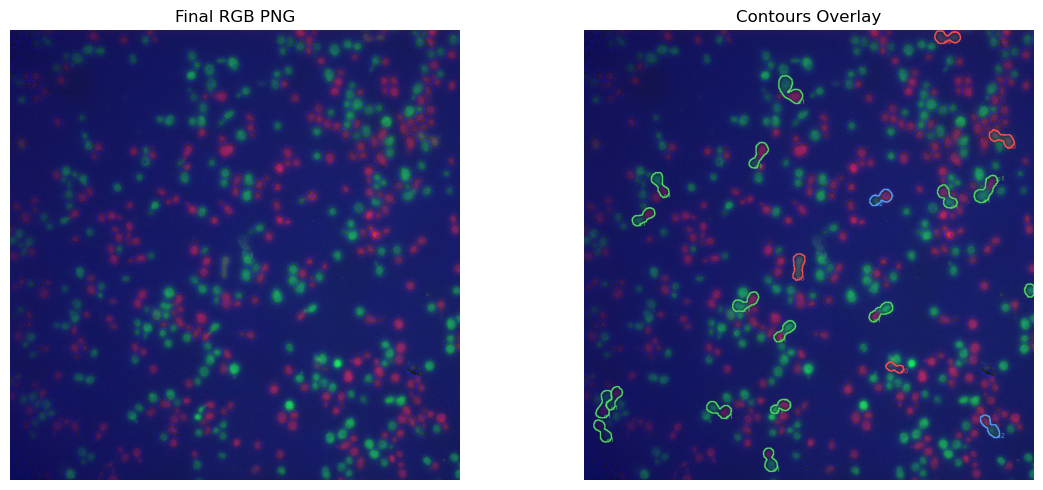


P1_1G7-18_25.png
  label: found
  contours parsed: 46


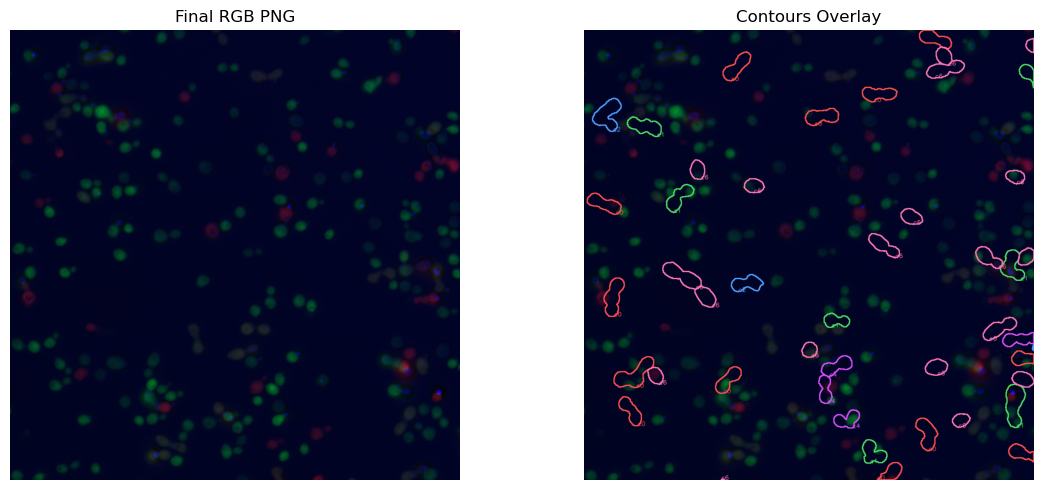


P1_1E3-13_22.png
  label: found
  contours parsed: 39


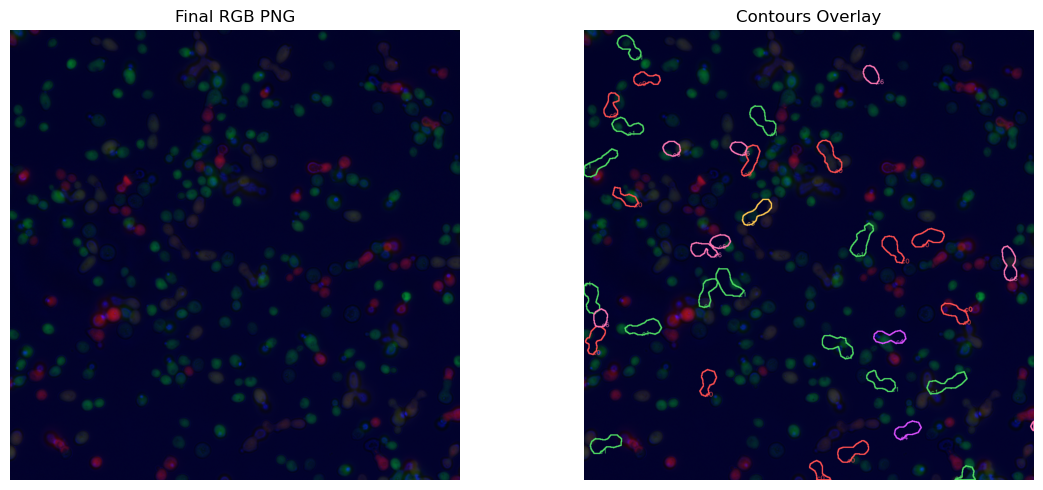


img_12.png
  label: found
  contours parsed: 20


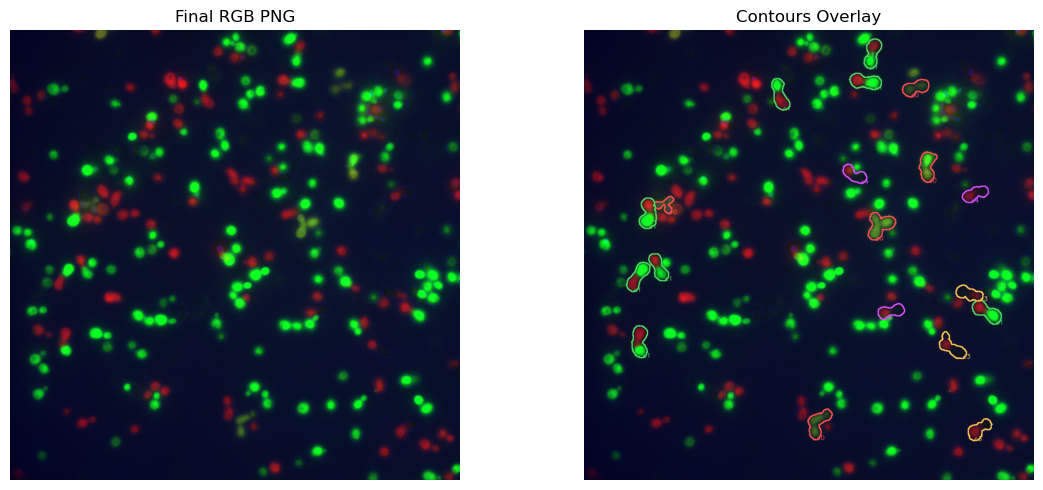


img_11.png
  label: found
  contours parsed: 23


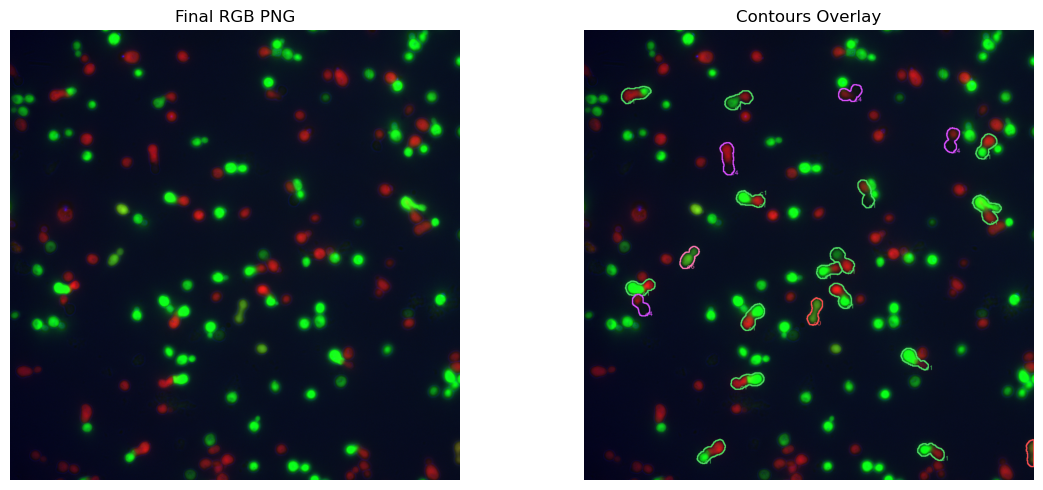


img_4.png
  label: found
  contours parsed: 28


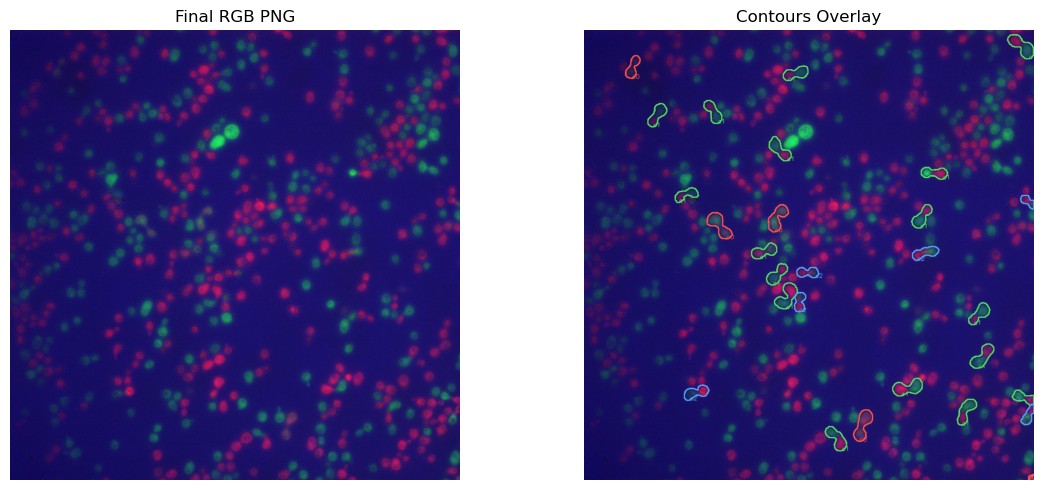

In [1]:
# Inspect final processed training samples (RGB PNG + contour polygons)
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Uses datasetdir if defined earlier in the notebook; otherwise defaults to datasets/
dataset_root = globals().get("datasetdir", "datasets/")
dataset_root = dataset_root.rstrip("/")

split_to_inspect = "train"  # change to "val" or "test" if needed
num_items_to_inspect = 6
random_seed = 42

images_dir = os.path.join(dataset_root, split_to_inspect, "images")
labels_dir = os.path.join(dataset_root, split_to_inspect, "labels")

png_files = sorted(glob.glob(os.path.join(images_dir, "*.png")))
if not png_files:
    raise FileNotFoundError(f"No PNG files found in: {images_dir}")

print(f"Inspecting split: {split_to_inspect}")
print(f"Images folder: {images_dir}")
print(f"Labels folder: {labels_dir}")
print(f"Total PNG images found: {len(png_files)}")

rng = random.Random(random_seed)
samples = png_files if len(png_files) <= num_items_to_inspect else rng.sample(png_files, num_items_to_inspect)

# Distinct colors for class IDs (cycled if classes > palette length)
palette = [
    (255, 80, 80),
    (80, 220, 100),
    (80, 160, 255),
    (255, 200, 80),
    (220, 80, 255),
    (80, 255, 240),
    (255, 120, 180),
]

def read_yolo_polygons(label_path, w, h):
    polygons = []
    if not os.path.exists(label_path):
        return polygons

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                # Need at least: class + 3 points (x1 y1 x2 y2 x3 y3)
                continue

            try:
                cls_id = int(float(parts[0]))
                coords = list(map(float, parts[1:]))
            except ValueError:
                continue

            if len(coords) % 2 != 0:
                continue

            pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
            pts[:, 0] *= w  # x normalized to image width
            pts[:, 1] *= h  # y normalized to image height
            polygons.append((cls_id, np.round(pts).astype(np.int32)))

    return polygons

for img_path in samples:
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, f"{base}.txt")

    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if bgr is None:
        print(f"[WARN] Could not read image: {img_path}")
        continue

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]

    overlay = rgb.copy()
    polygons = read_yolo_polygons(label_path, w, h)

    for cls_id, poly in polygons:
        color = palette[cls_id % len(palette)]
        cv2.polylines(overlay, [poly], isClosed=True, color=color, thickness=2)
        if len(poly) > 0:
            p0 = tuple(poly[0])
            cv2.putText(
                overlay,
                f"c{cls_id}",
                p0,
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                color,
                1,
                cv2.LINE_AA,
            )

    print(f"\n{os.path.basename(img_path)}")
    print(f"  label: {'found' if os.path.exists(label_path) else 'missing'}")
    print(f"  contours parsed: {len(polygons)}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Final RGB PNG")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Contours Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()